# Animal10: EDA

#TODO

confusion matrix prelozit

resnet too heavy

weighted test acc

pozriet co je bottleneck pri treningu


## 1. Importy a nastavenie prostredia

V tejto časti načítame knižnice, nastavíme seed pre reprodukovateľnosť a pripravíme si jednoduché vizuálne nastavenia grafov.

In [1]:


import hashlib
from pathlib import Path
import random
import sys
import warnings
import os
import wandb

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
import torch.nn.functional as F

import cv2

from torchvision import transforms, models
from torchvision.models import (
    ResNet18_Weights,
)

from tqdm.auto import tqdm

from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, classification_report, roc_auc_score, precision_score, recall_score

from dotenv import load_dotenv

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import Markdown, display
from PIL import Image
from sklearn.model_selection import train_test_split

from animal10_dataset import Animal10Dataset

warnings.filterwarnings("ignore")
random.seed(42)
np.random.seed(42)

plt.style.use("seaborn-v0_8-whitegrid")
sns.set_theme(style="whitegrid", context="notebook")
pd.set_option("display.max_columns", 50)
pd.set_option("display.max_rows", 20)


/Users/romankosik/PycharmProjects/Neuronove_siete/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 2. Načítanie cesty k datasetu a preklad názvov tried

Tu si pripravíme cestu k datasetu a použijeme vstavaný súbor `archive/translate.py`.

Dataset používa talianske názvy priečinkov (`cane`, `gatto`, `ragno`, ...), ale pre EDA je praktickejšie zobrazovať aj anglický ekvivalent. Preto slovník z `translate.py` načítame a upravíme do mapovania `taliančina -> angličtina`.


In [2]:
DATA_ROOT = Path("dataset_utils/raw-img")

from dataset_utils.translate import translate as raw_translate

class_dirs = sorted([p.name for p in DATA_ROOT.iterdir() if p.is_dir()])

# Z `translate.py` vytvoríme smer taliančina -> angličtina.
# V súbore sú totiž niektoré dvojice aj opačne, preto si pomôžeme aj inverziou slovníka.
inverse_translate = {value: key for key, value in raw_translate.items() if isinstance(key, str) and isinstance(value, str)}

CLASS_TO_ENGLISH = {}
for class_name in class_dirs:
    if class_name in raw_translate and raw_translate[class_name] not in class_dirs:
        CLASS_TO_ENGLISH[class_name] = raw_translate[class_name]
    elif class_name in inverse_translate and inverse_translate[class_name] not in class_dirs:
        CLASS_TO_ENGLISH[class_name] = inverse_translate[class_name]
    else:
        CLASS_TO_ENGLISH[class_name] = class_name

CLASS_TO_ENGLISH


{'cane': 'dog',
 'cavallo': 'horse',
 'elefante': 'elephant',
 'farfalla': 'butterfly',
 'gallina': 'chicken',
 'gatto': 'cat',
 'mucca': 'cow',
 'pecora': 'sheep',
 'ragno': 'spider',
 'scoiattolo': 'squirrel'}

## 2.1 Rýchly náhľad obrázkov

Ešte pred detailnou analýzou si zobrazíme po jednom obrázku z každej triedy, aby sme mali rýchly vizuálny prehľad o tom, ako dataset vyzerá.

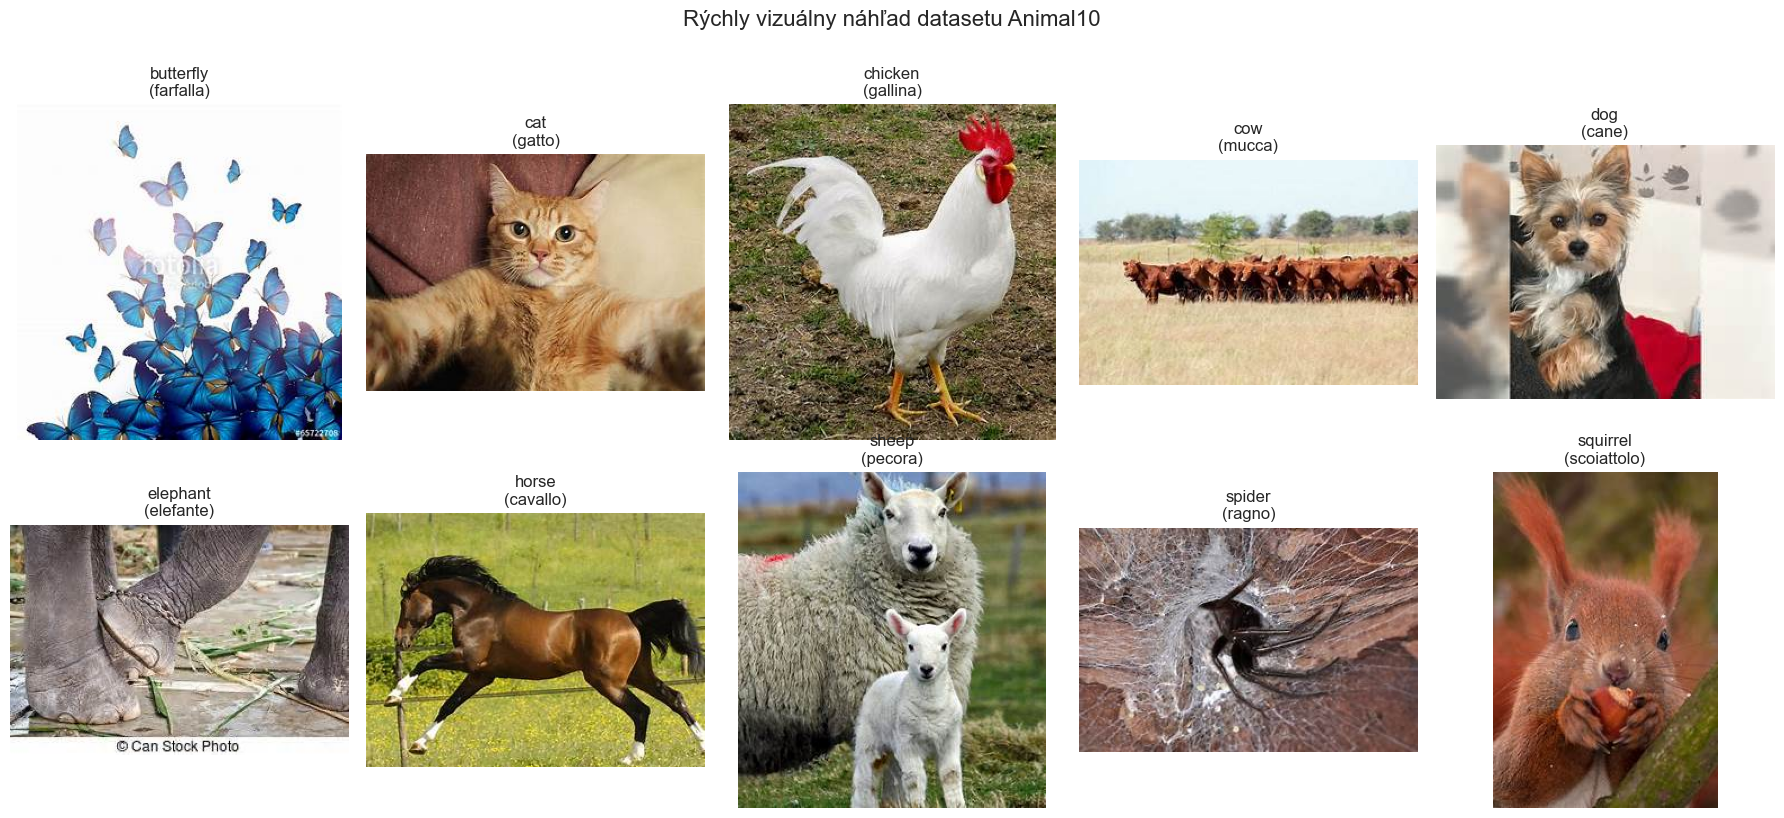

In [3]:
preview_rows = []

for class_name in class_dirs:
    class_path = DATA_ROOT / class_name
    image_files = sorted([p for p in class_path.iterdir() if p.is_file()])
    if image_files:
        preview_rows.append(
            {
                "class_it": class_name,
                "class_en": CLASS_TO_ENGLISH.get(class_name, class_name),
                "path": str(image_files[0]),
            }
        )

preview_df = pd.DataFrame(preview_rows).sort_values("class_en")

fig, axes = plt.subplots(2, 5, figsize=(18, 8))
axes = axes.flatten()

for ax, (_, row) in zip(axes, preview_df.iterrows()):
    with Image.open(row["path"]) as img:
        img = img.convert("RGB")
        ax.imshow(img)
    ax.set_title(f"{row['class_en']}\n({row['class_it']})")
    ax.axis("off")

plt.suptitle("Rýchly vizuálny náhľad datasetu Animal10", y=1.02, fontsize=16)
plt.tight_layout()
plt.show()


## 3. DF

V tejto bunke prejdeme všetky priečinky tried, načítame metadáta o obrázkoch a uložíme ich do tabuľky `df`.

Pre každý obrázok si uložíme:
- triedu v taliančine,
- preloženú triedu v angličtine,
- názov súboru a cestu,
- šírku, výšku, pomer strán a počet pixelov,
- formát a farebný mód,
- orientáciu obrázka.

Ak sa nejaký súbor nepodarí otvoriť, uloží sa do `bad_df`, aby sme vedeli odhaliť poškodené dáta.


In [4]:
records = []
bad_files = []

for class_dir in sorted([p for p in DATA_ROOT.iterdir() if p.is_dir()]):
    for image_path in sorted([p for p in class_dir.iterdir() if p.is_file()]):
        try:
            with Image.open(image_path) as img:
                width, height = img.size
                image_format = img.format
                image_mode = img.mode

            records.append(
                {
                    "class_it": class_dir.name,
                    "class_en": CLASS_TO_ENGLISH.get(class_dir.name, class_dir.name),
                    "file_name": image_path.name,
                    "path": str(image_path),
                    "extension": image_path.suffix.lower(),
                    "width": width,
                    "height": height,
                    "aspect_ratio": width / height,
                    "pixels": width * height,
                    "format": image_format,
                    "mode": image_mode,
                    "orientation": "skoro_stvorec" if abs(width - height) <= 10 else ("na_sirku" if width > height else "na_vysku"),
                }
            )
        except Exception as exc:
            bad_files.append({"path": str(image_path), "error": repr(exc)})

df = pd.DataFrame(records)
bad_df = pd.DataFrame(bad_files)

print(f"Pocet tried: {df['class_it'].nunique()}")
print(f"Pocet nacitanych obrazkov: {len(df):,}")
print(f"Pocet necitatelnych suborov: {len(bad_df):,}")


Pocet tried: 10
Pocet nacitanych obrazkov: 26,179
Pocet necitatelnych suborov: 0


## 4. Základný prehľad datasetu

Teraz z pripraveného `DataFrame` vytvoríme základné sumáre:
- koľko je tried a obrázkov,
- koľko obrázkov pripadá na jednotlivé triedy,
- aká výrazná je nevyváženosť tried,
- či máme viac prípon, formátov alebo farebných módov.

Táto časť je dôležitá hlavne preto, aby sme ešte pred tréningom vedeli, či bude treba riešiť balancing alebo vhodnejšie metriky.


In [5]:
class_counts = (
    df.groupby(["class_it", "class_en"], as_index=False)
    .size()
    .rename(columns={"size": "images"})
    .sort_values("images", ascending=False)
)

overview = pd.DataFrame(
    {
        "metrika": [
            "pocet_tried",
            "pocet_obrazkov",
            "minimum_na_triedu",
            "maximum_na_triedu",
            "priemer_na_triedu",
            "median_na_triedu",
            "pomer_najvacsia_najmensia",
            "pocet_pripon",
            "pocet_formatov",
            "pocet_modov",
        ],
        "hodnota": [
            int(df["class_it"].nunique()),
            int(len(df)),
            int(class_counts["images"].min()),
            int(class_counts["images"].max()),
            round(class_counts["images"].mean(), 2),
            round(class_counts["images"].median(), 2),
            round(class_counts["images"].max() / class_counts["images"].min(), 2),
            int(df["extension"].nunique()),
            int(df["format"].nunique()),
            int(df["mode"].nunique()),
        ],
    }
)

display(Markdown("## Prehľad datasetu"))
display(overview)

display(Markdown("## Prvé riadky tabuľky"))
display(df.head())

display(Markdown("## Počet obrázkov v jednotlivých triedach"))
display(class_counts)

if not bad_df.empty:
    display(Markdown("## Problematické súbory"))
    display(bad_df.head())


## Prehľad datasetu

,metrika,hodnota
0,pocet_tried,10.00
1,pocet_obrazkov,26179.00
2,minimum_na_triedu,1446.00
3,maximum_na_triedu,4863.00
4,priemer_na_triedu,2617.90
5,median_na_triedu,1989.00
6,pomer_najvacsia_najmensia,3.36
7,pocet_pripon,3.00
8,pocet_formatov,2.00
9,pocet_modov,4.00


## Prvé riadky tabuľky

,class_it,class_en,file_name,path,extension,width,height,aspect_ratio,pixels,format,mode,orientation
0,cane,dog,OIF-e2bexWrojgtQnAPPcUfOWQ.jpeg,dataset_utils/raw-img/cane/OIF-e2bexWrojgtQnAP...,.jpeg,300,225,1.333333,67500,JPEG,RGB,na_sirku
1,cane,dog,OIP---A27bIBcUgX1qkbpZOPswHaFS.jpeg,dataset_utils/raw-img/cane/OIP---A27bIBcUgX1qk...,.jpeg,300,214,1.401869,64200,JPEG,RGB,na_sirku
2,cane,dog,OIP---ZIdwfUcJeVxnh47zppcQHaFj.jpeg,dataset_utils/raw-img/cane/OIP---ZIdwfUcJeVxnh...,.jpeg,300,225,1.333333,67500,JPEG,RGB,na_sirku
3,cane,dog,OIP---ZRsOF7zsMqhW30WeF8-AHaFj.jpeg,dataset_utils/raw-img/cane/OIP---ZRsOF7zsMqhW3...,.jpeg,300,225,1.333333,67500,JPEG,RGB,na_sirku
4,cane,dog,OIP---_cJbI6Ei26w5bW1urHewHaCf.jpeg,dataset_utils/raw-img/cane/OIP---_cJbI6Ei26w5b...,.jpeg,300,101,2.970297,30300,JPEG,RGB,na_sirku


## Počet obrázkov v jednotlivých triedach

,class_it,class_en,images
0,cane,dog,4863
8,ragno,spider,4821
4,gallina,chicken,3098
1,cavallo,horse,2623
3,farfalla,butterfly,2112
6,mucca,cow,1866
9,scoiattolo,squirrel,1862
7,pecora,sheep,1820
5,gatto,cat,1668
2,elefante,elephant,1446


### Ako čítať tento prehľad

Táto tabuľka je rýchly sanity check datasetu. Sledujeme najmä počet tried, celkový počet obrázkov a to, či nie je dataset extrémne nevyvážený.

V našom prípade je tried `10` a spolu máme `26179` obrázkov. Rozptyl medzi triedami existuje, ale nie je dramatický: minimum je `1446` a maximum `4863` obrázkov na triedu. To znamená, že model síce môže mať mierne výhodu na početnejších triedach, ale nejde o takú nevyváženosť, ktorá by sama osebe znemožňovala tréning.


## 5. Vizualizácia tried, formátov a prípon

V tejto časti si graficky ukážeme:
- rozdelenie obrázkov medzi triedy,
- aké prípony súborov sa v datasete nachádzajú,
- v akých obrazových formátoch sú dáta uložené.

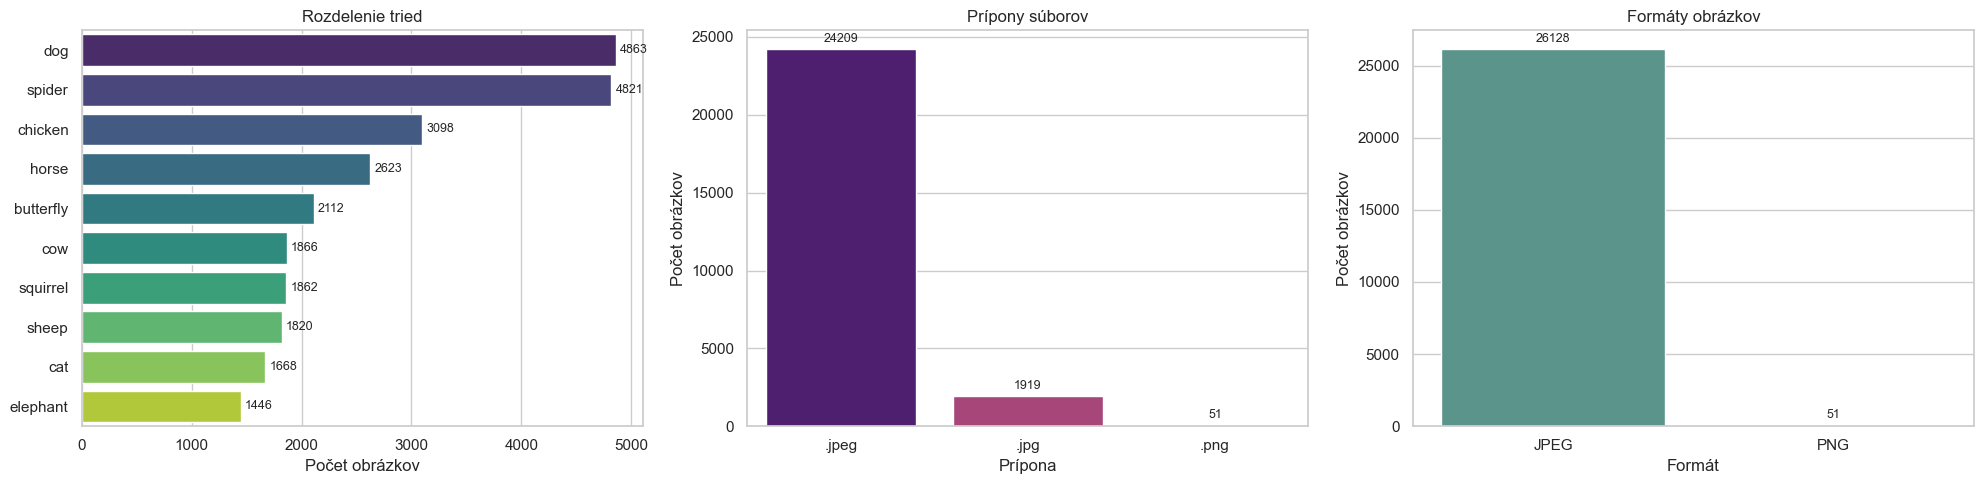

### Farebné módy

,mode,images
0,RGB,26128
1,RGBA,49
2,L,1
3,CMYK,1


In [6]:
format_counts = df["format"].value_counts().rename_axis("format").reset_index(name="images")
mode_counts = df["mode"].value_counts().rename_axis("mode").reset_index(name="images")
extension_counts = df["extension"].value_counts().rename_axis("extension").reset_index(name="images")

def add_bar_labels(ax, fmt="{:.0f}"):
    for container in ax.containers:
        labels = []
        for value in container.datavalues:
            if pd.isna(value):
                labels.append("")
            else:
                labels.append(fmt.format(value))
        ax.bar_label(container, labels=labels, padding=3, fontsize=9)

fig, axes = plt.subplots(1, 3, figsize=(20, 5))

sns.barplot(data=class_counts, x="images", y="class_en", palette="viridis", ax=axes[0])
axes[0].set_title("Rozdelenie tried")
axes[0].set_xlabel("Počet obrázkov")
axes[0].set_ylabel("")
add_bar_labels(axes[0])

sns.barplot(data=extension_counts, x="extension", y="images", palette="magma", ax=axes[1])
axes[1].set_title("Prípony súborov")
axes[1].set_xlabel("Prípona")
axes[1].set_ylabel("Počet obrázkov")
add_bar_labels(axes[1])

sns.barplot(data=format_counts, x="format", y="images", palette="crest", ax=axes[2])
axes[2].set_title("Formáty obrázkov")
axes[2].set_xlabel("Formát")
axes[2].set_ylabel("Počet obrázkov")
add_bar_labels(axes[2])

plt.tight_layout()
plt.show()

display(Markdown("### Farebné módy"))
display(mode_counts)


### Čo sledovať na grafoch formátov a prípon

Prvý graf ukazuje zastúpenie tried, ďalšie dva hovoria o technickej kvalite datasetu: v akých formátoch sú obrázky uložené a aké prípony sa v dátach objavujú. To je dôležité najmä preto, aby nás neskôr neprekvapili netypické súbory pri načítavaní.

Vidíme, že dataset je prakticky celý v režime `RGB` (`26128` obrázkov). Len malé množstvo tvorí `RGBA`, `L` alebo `CMYK`, takže konverzia do `RGB` v pipeline je skôr poistka než riešenie veľkého problému.


## 6. Analýza rozmerov obrázkov

Keďže pri klasifikácii budeme obrázky neskôr resizeovať na fixný rozmer, potrebujeme vedieť, aká je aktuálna distribúcia šírok, výšok a pomerov strán.

Táto bunka zhrnie základné štatistiky a zároveň zobrazí histogramy a scatter plot `width vs. height` na vzorke dát.


,metrika,hodnota
0,width_min,60.000
1,width_max,6720.000
2,width_mean,320.040
3,width_median,300.000
4,height_min,57.000
5,height_max,6000.000
6,height_mean,252.630
7,height_median,225.000
8,aspect_ratio_min,0.293
9,aspect_ratio_max,4.225


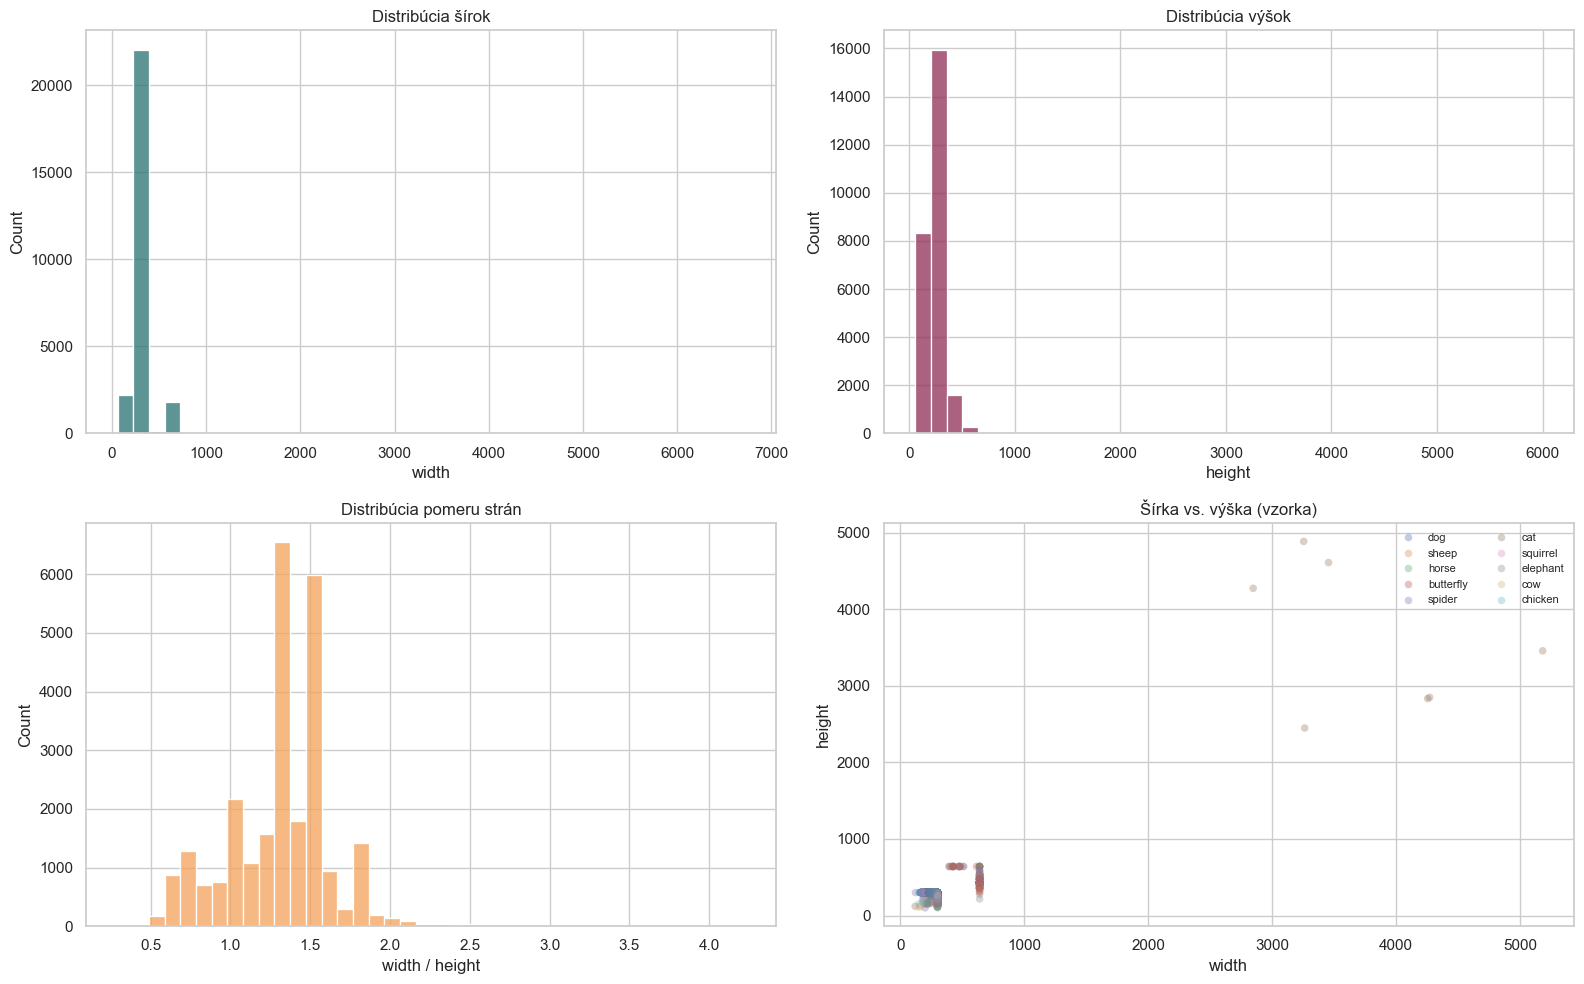

### Najčastejšie rozmery obrázkov

,width,height,images
0,300,225,4397
1,300,200,3281
2,300,300,1192
3,300,169,1048
4,640,426,694
5,300,199,586
6,225,300,490
7,300,240,403
8,300,188,393
9,200,300,362


In [7]:
size_summary = pd.DataFrame(
    {
        "metrika": [
            "width_min",
            "width_max",
            "width_mean",
            "width_median",
            "height_min",
            "height_max",
            "height_mean",
            "height_median",
            "aspect_ratio_min",
            "aspect_ratio_max",
            "aspect_ratio_mean",
            "pixels_median",
        ],
        "hodnota": [
            int(df["width"].min()),
            int(df["width"].max()),
            round(df["width"].mean(), 2),
            round(df["width"].median(), 2),
            int(df["height"].min()),
            int(df["height"].max()),
            round(df["height"].mean(), 2),
            round(df["height"].median(), 2),
            round(df["aspect_ratio"].min(), 3),
            round(df["aspect_ratio"].max(), 3),
            round(df["aspect_ratio"].mean(), 3),
            int(df["pixels"].median()),
        ],
    }
)

display(size_summary)

fig, axes = plt.subplots(2, 2, figsize=(16, 10))

sns.histplot(df["width"], bins=40, color="#287271", ax=axes[0, 0])
axes[0, 0].set_title("Distribúcia šírok")

sns.histplot(df["height"], bins=40, color="#8f2d56", ax=axes[0, 1])
axes[0, 1].set_title("Distribúcia výšok")

sns.histplot(df["aspect_ratio"], bins=40, color="#f4a259", ax=axes[1, 0])
axes[1, 0].set_title("Distribúcia pomeru strán")
axes[1, 0].set_xlabel("width / height")

sample_for_scatter = df.sample(n=min(4000, len(df)), random_state=42)
sns.scatterplot(
    data=sample_for_scatter,
    x="width",
    y="height",
    hue="class_en",
    alpha=0.35,
    s=30,
    linewidth=0,
    ax=axes[1, 1],
)
axes[1, 1].set_title("Šírka vs. výška (vzorka)")
axes[1, 1].legend(loc="upper right", fontsize=8, ncol=2)

plt.tight_layout()
plt.show()

display(Markdown("### Najčastejšie rozmery obrázkov"))
display(df[["width", "height"]].value_counts().head(15).rename("images").reset_index())


### Interpretácia rozmerov obrázkov

Tu sledujeme, aké veľké a aké rôznorodé sú vstupné obrázky. Pre model je podstatné, že pôvodné rozmery nie sú jednotné, takže resize a crop v pipeline nie sú voliteľný luxus, ale nutný krok.

Priemerné rozmery sú približne `320 x 253` pixelov, ale maximum ide až do tisícov pixelov. Histogramy preto hovoria, že dataset kombinuje menšie webové obrázky aj väčšie fotografie. Pri takejto heterogenite je dôležité zvoliť pevný vstupný rozmer pre model a zároveň si uvedomiť, že pri center crope môžeme na niektorých vzorkách prísť o časť kontextu.


## 7. Orientácia obrázkov a rozdiely medzi triedami

Tu sa pozeráme na to, či sú obrázky častejšie orientované na šírku, na výšku alebo sú takmer štvorcové.

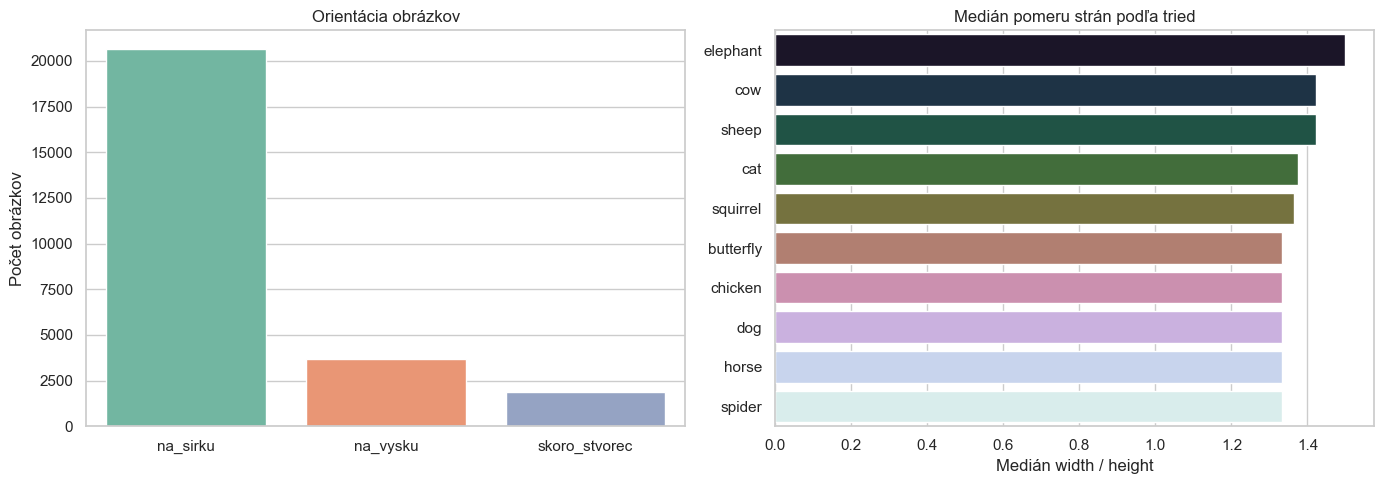

,orientation,images
0,na_sirku,20639
1,na_vysku,3658
2,skoro_stvorec,1882


,class_en,width,height,aspect_ratio
5,elephant,300.0,225.0,1.500000
3,cow,300.0,209.0,1.421801
7,sheep,300.0,225.0,1.421801
1,cat,300.0,243.5,1.376147
9,squirrel,300.0,217.0,1.363636
0,butterfly,300.0,230.0,1.333333
2,chicken,300.0,225.0,1.333333
4,dog,300.0,225.0,1.333333
6,horse,300.0,225.0,1.333333
8,spider,300.0,225.0,1.333333


In [8]:
orientation_counts = (
    df["orientation"].value_counts().rename_axis("orientation").reset_index(name="images")
)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.barplot(data=orientation_counts, x="orientation", y="images", palette="Set2", ax=axes[0])
axes[0].set_title("Orientácia obrázkov")
axes[0].set_xlabel("")
axes[0].set_ylabel("Počet obrázkov")

median_by_class = (
    df.groupby("class_en", as_index=False)[["width", "height", "aspect_ratio"]]
    .median()
    .sort_values("aspect_ratio", ascending=False)
)
sns.barplot(data=median_by_class, x="aspect_ratio", y="class_en", palette="cubehelix", ax=axes[1])
axes[1].set_title("Medián pomeru strán podľa tried")
axes[1].set_xlabel("Medián width / height")
axes[1].set_ylabel("")

plt.tight_layout()
plt.show()

display(orientation_counts)
display(median_by_class)


### Čo nám hovorí orientácia a pomer strán

Tento blok pomáha pochopiť, či sú dáta prevažne na šírku, na výšku alebo takmer štvorcové, a či sa niektoré triedy systematicky odlišujú. To je užitočné pri rozhodovaní, či je center crop rozumný a kde môže model prichádzať o informáciu.

Výrazná väčšina obrázkov je `na_sirku` (`20639`), zatiaľ čo obrázkov `na_vysku` je podstatne menej (`3658`). Z pohľadu tried sa mierne odlišujú napríklad `elephant`, `cow` alebo `sheep`, ktoré majú vyšší medián pomeru strán. Praktický dôsledok je, že jednotný crop funguje, ale pri niektorých triedach môže viac orezať okraje tela alebo pozadie než pri iných.


## 8. Predpríprava dát pre modelovanie

V tejto sekcii pripravíme dataset do podoby, ktorú budeme vedieť rovno použiť pri tréningu modelov.

Bez ohľadu na to, aký model budeme testovať neskôr, je užitočné mať:
- jednotné ID tried,
- prehľadný manifest so všetkými metadátami,
- informáciu, ktoré obrázky treba pri načítaní previesť na `RGB`,
- stratifikovaný train/validation/test split,
- uložené CSV súbory, aby sme nemuseli split robiť nanovo pri každom notebooku alebo skripte.


In [9]:
import hashlib
from sklearn.model_selection import train_test_split

def file_md5(path, chunk_size=1024 * 1024):
    hasher = hashlib.md5()
    with open(path, "rb") as f:
        while True:
            chunk = f.read(chunk_size)
            if not chunk:
                break
            hasher.update(chunk)
    return hasher.hexdigest()

prepared_df = df.copy()
prepared_df["relative_path"] = prepared_df["path"].apply(lambda p: Path(p).as_posix())
prepared_df["needs_rgb_conversion"] = prepared_df["mode"] != "RGB"
prepared_df["content_hash"] = prepared_df["path"].apply(file_md5)

label_order = sorted(prepared_df["class_it"].unique())
label_to_id = {label: idx for idx, label in enumerate(label_order)}
id_to_label = {idx: label for label, idx in label_to_id.items()}

prepared_df["target_id"] = prepared_df["class_it"].map(label_to_id)
prepared_df["split"] = "unassigned"

train_df, temp_df = train_test_split(
    prepared_df,
    test_size=0.30,
    random_state=42,
    stratify=prepared_df["class_it"],
)
val_df, test_df = train_test_split(
    temp_df,
    test_size=0.50,
    random_state=42,
    stratify=temp_df["class_it"],
)

prepared_df.loc[train_df.index, "split"] = "train"
prepared_df.loc[val_df.index, "split"] = "val"
prepared_df.loc[test_df.index, "split"] = "test"

duplicate_summary = (
    prepared_df.groupby("content_hash")
    .size()
    .rename("count")
    .reset_index()
    .query("count > 1")
    .sort_values("count", ascending=False)
)

split_summary = (
    prepared_df.groupby(["split", "class_en"], as_index=False)
    .size()
    .rename(columns={"size": "images"})
    .sort_values(["split", "class_en"])
)

prep_summary = pd.DataFrame(
    {
        "metrika": [
            "pocet_zaznamov_v_manifeste",
            "pocet_unikatnych_hashov",
            "pocet_hash_duplicit",
            "obrazky_mimo_RGB",
            "train_pocet",
            "val_pocet",
            "test_pocet",
        ],
        "hodnota": [
            int(len(prepared_df)),
            int(prepared_df["content_hash"].nunique()),
            int(len(duplicate_summary)),
            int(prepared_df["needs_rgb_conversion"].sum()),
            int((prepared_df["split"] == "train").sum()),
            int((prepared_df["split"] == "val").sum()),
            int((prepared_df["split"] == "test").sum()),
        ],
    }
)

artifacts_dir = Path("artifacts/animal10")
artifacts_dir.mkdir(parents=True, exist_ok=True)

prepared_df.to_csv(artifacts_dir / "animal10_manifest.csv", index=False)
prepared_df.query("split == 'train'").to_csv(artifacts_dir / "animal10_train.csv", index=False)
prepared_df.query("split == 'val'").to_csv(artifacts_dir / "animal10_val.csv", index=False)
prepared_df.query("split == 'test'").to_csv(artifacts_dir / "animal10_test.csv", index=False)
pd.DataFrame(
    {
        "class_it": label_order,
        "class_en": [CLASS_TO_ENGLISH[label] for label in label_order],
        "target_id": [label_to_id[label] for label in label_order],
    }
).to_csv(artifacts_dir / "animal10_label_mapping.csv", index=False)

display(Markdown("### Zhrnutie predprípravy"))
display(prep_summary)

display(Markdown("### Rozdelenie tried podľa splitu"))
display(split_summary)

if not duplicate_summary.empty:
    display(Markdown("### Potenciálne duplicitné obrázky podľa hash-u"))
    display(duplicate_summary.head(20))

display(Markdown(f"### Súbory uložené do `{artifacts_dir}`"))
display(sorted([p.name for p in artifacts_dir.iterdir() if p.is_file()]))


### Zhrnutie predprípravy

,metrika,hodnota
0,pocet_zaznamov_v_manifeste,26179
1,pocet_unikatnych_hashov,26179
2,pocet_hash_duplicit,0
3,obrazky_mimo_RGB,51
4,train_pocet,18325
5,val_pocet,3927
6,test_pocet,3927


### Rozdelenie tried podľa splitu

,split,class_en,images
0,test,butterfly,317
1,test,cat,250
2,test,chicken,465
3,test,cow,280
4,test,dog,730
...,...,...,...
25,val,elephant,217
26,val,horse,394
27,val,sheep,273
28,val,spider,723


### Súbory uložené do `artifacts/animal10`

['animal10_label_mapping.csv',
 'animal10_manifest.csv',
 'animal10_test.csv',
 'animal10_train.csv',
 'animal10_val.csv']

## 9. Pipeline

Táto pipeline nerobí nevratné zmeny do súborov na disku. Transformácie sa aplikujú až pri načítaní dát, čo je výhodné, lebo ich vieme neskôr ľahko meniť.

Základné kroky sú:
- prevod na `RGB`, aby mali všetky obrázky rovnaký počet kanálov,
- resize na trochu väčší rozmer a následný crop na `224x224`,
- prevod na tensor,
- normalizácia pixelov.


In [10]:
import torch
from torchvision import transforms

IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD = [0.229, 0.224, 0.225]
INPUT_SIZE = 224
RESIZE_SIZE = 256

train_transforms = transforms.Compose([
    transforms.Lambda(lambda img: img.convert("RGB")),
    transforms.Resize(RESIZE_SIZE),
    transforms.CenterCrop(INPUT_SIZE),
    transforms.ToTensor(),
    transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
])

eval_transforms = transforms.Compose([
    transforms.Lambda(lambda img: img.convert("RGB")),
    transforms.Resize(RESIZE_SIZE),
    transforms.CenterCrop(INPUT_SIZE),
    transforms.ToTensor(),
    transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
])

sample_row = prepared_df.iloc[0]
with Image.open(sample_row["path"]) as sample_img:
    sample_tensor = eval_transforms(sample_img)

pipeline_summary = pd.DataFrame(
    {
        "krok": [
            "convert_to_rgb",
            "resize",
            "center_crop",
            "to_tensor",
            "normalize",
        ],
        "popis": [
            "zjednotenie počtu kanálov na 3",
            f"kratšia strana sa upraví na približne {RESIZE_SIZE} px",
            f"výsledný vstup do modelu bude {INPUT_SIZE}x{INPUT_SIZE}",
            "obrázok sa prevedie na tensor tvaru C x H x W",
            "normalizácia podľa ImageNet mean/std",
        ],
    }
)

display(Markdown("### Navrhovaná pipeline"))
display(pipeline_summary)

print("Ukážkový tensor po transformácii:")
print("shape:", tuple(sample_tensor.shape))
print("dtype:", sample_tensor.dtype)
print("min:", float(sample_tensor.min()))
print("max:", float(sample_tensor.max()))


### Navrhovaná pipeline

,krok,popis
0,convert_to_rgb,zjednotenie počtu kanálov na 3
1,resize,kratšia strana sa upraví na približne 256 px
2,center_crop,výsledný vstup do modelu bude 224x224
3,to_tensor,obrázok sa prevedie na tensor tvaru C x H x W
4,normalize,normalizácia podľa ImageNet mean/std


Ukážkový tensor po transformácii:
shape: (3, 224, 224)
dtype: torch.float32
min: -2.0836544036865234
max: 2.517995834350586


### Čo sme si overili na pipeline

Výstup potvrdzuje, že každý obrázok po transformácii skončí ako tensor tvaru `(3, 224, 224)`, teda v jednotnom formáte vhodnom pre CNN aj ResNet.

Rozsah hodnôt po normalizácii už nie je v intervale `0-1`, čo je očakávané, pretože používame ImageNet mean/std. To je dôležité hlavne pri transfer learningu, aby vstupy zodpovedali tomu, na čom bol predtrénovaný backbone pôvodne učený.


## 10. Tréningové prostredie a načítanie splitov

Nasledujúce bunky pripravia runtime pre tréning a evaluáciu. Prihlásime `wandb`, nastavíme seed a zariadenie, a potom načítame už pripravené CSV split-y z predchádzajúcej sekcie.

Cieľom je mať reprodukovateľný experiment a zároveň presne oddelené `train`, `val` a `test` dáta, aby sme neskôr nehodnotili model na tom, čo už počas učenia videl.


In [11]:
load_dotenv()
os.environ["WANDB_API_KEY"] = os.getenv('WANDB_API_KEY')

wandb.login()

wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from WANDB_API_KEY.
wandb: Currently logged in as: xkosik (xkosik-) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


True

In [12]:
def set_seed(seed: int = 42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

set_seed(42)

torch.backends.cudnn.benchmark = True

DEVICE = (
    "cuda" if torch.cuda.is_available()
    else "mps" if torch.backends.mps.is_available()
    else "cpu"
)
DEVICE

'mps'

In [13]:
ARTIFACTS_DIR = Path("artifacts/animal10")

train_csv = ARTIFACTS_DIR / "animal10_train.csv"
val_csv   = ARTIFACTS_DIR / "animal10_val.csv"
test_csv  = ARTIFACTS_DIR / "animal10_test.csv"

train_df = pd.read_csv(train_csv)
val_df   = pd.read_csv(val_csv)
test_df  = pd.read_csv(test_csv)

print(len(train_df), len(val_df), len(test_df))
train_df.head()

18325 3927 3927


,class_it,class_en,file_name,path,extension,width,height,aspect_ratio,pixels,format,mode,orientation,relative_path,needs_rgb_conversion,content_hash,target_id,split
0,cane,dog,OIF-e2bexWrojgtQnAPPcUfOWQ.jpeg,dataset_utils/raw-img/cane/OIF-e2bexWrojgtQnAP...,.jpeg,300,225,1.333333,67500,JPEG,RGB,na_sirku,dataset_utils/raw-img/cane/OIF-e2bexWrojgtQnAP...,False,fda3a63b57bb6bdf0b1af8ec110310be,0,train
1,cane,dog,OIP---A27bIBcUgX1qkbpZOPswHaFS.jpeg,dataset_utils/raw-img/cane/OIP---A27bIBcUgX1qk...,.jpeg,300,214,1.401869,64200,JPEG,RGB,na_sirku,dataset_utils/raw-img/cane/OIP---A27bIBcUgX1qk...,False,1d5e33460ed7a824f7c29e305fb81c94,0,train
2,cane,dog,OIP---ZIdwfUcJeVxnh47zppcQHaFj.jpeg,dataset_utils/raw-img/cane/OIP---ZIdwfUcJeVxnh...,.jpeg,300,225,1.333333,67500,JPEG,RGB,na_sirku,dataset_utils/raw-img/cane/OIP---ZIdwfUcJeVxnh...,False,c3331f98db767ea625165b4accf78261,0,train
3,cane,dog,OIP--0C2kq6I68beB3DduLoxMgHaEf.jpeg,dataset_utils/raw-img/cane/OIP--0C2kq6I68beB3D...,.jpeg,300,182,1.648352,54600,JPEG,RGB,na_sirku,dataset_utils/raw-img/cane/OIP--0C2kq6I68beB3D...,False,b6b0671ef86c8a43c709969abf8bdbaf,0,train
4,cane,dog,OIP--0CZnfLuBERVtzRm2QbB3gHaK4.jpeg,dataset_utils/raw-img/cane/OIP--0CZnfLuBERVtzR...,.jpeg,205,300,0.683333,61500,JPEG,RGB,na_vysku,dataset_utils/raw-img/cane/OIP--0CZnfLuBERVtzR...,False,6025cd534fa3cd741ab032f922c51a75,0,train


In [14]:
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD = [0.229, 0.224, 0.225]
INPUT_SIZE = 224
RESIZE_SIZE = 256
NUM_CLASSES = train_df["target_id"].nunique()


### Čo sme zistili o prostredí a dátach

Notebook sa úspešne prihlásil do `wandb`, takže metriky a checkpointy vieme logovať externe bez ďalšej ručnej konfigurácie.

Ako výpočtové zariadenie sa vybral `mps`, teda Apple Metal backend. Split-y majú veľkosti `18325 / 3927 / 3927`, čo zodpovedá pripravenému rozdeleniu z predprípravy. Náhľad `train_df.head()` zároveň potvrdzuje, že v CSV máme všetky dôležité metadáta: cestu k súboru, rozmery, mód, hash aj `target_id`.


## 11. Definícia modelov a experimentov

V tejto časti si pripravíme všetko, čo model potrebuje na učenie: transformácie s augmentáciou, dataset/dataloader, architektúry, optimizer, scheduler a samotnú tréningovú slučku.

Na konci zadefinujeme viacero experimentov, aby sme vedeli porovnať jednoduchý vlastný model, hlbší CNN model a transfer learning cez `resnet18`, vrátane frozen-head a fine-tuning variantu.


In [15]:
def build_transforms(augmented: bool, aug_prob: float):
    if augmented:
        train_tfms = transforms.Compose([
            transforms.Resize((RESIZE_SIZE, RESIZE_SIZE)),
            transforms.RandomApply(
                [
                    transforms.RandomResizedCrop(INPUT_SIZE, scale=(0.75, 1.0), ratio=(0.9, 1.1)),
                    transforms.RandomHorizontalFlip(p=1.0),
                    transforms.RandomRotation(degrees=15),
                    transforms.ColorJitter(
                        brightness=0.2,
                        contrast=0.2,
                        saturation=0.2,
                        hue=0.03,
                    ),
                    transforms.RandomAffine(
                        degrees=0,
                        translate=(0.08, 0.08),
                        scale=(0.95, 1.05),
                    ),
                    transforms.RandomPerspective(distortion_scale=0.15, p=0.5),
                ],
                p=aug_prob,  
            ),
            transforms.Resize((INPUT_SIZE, INPUT_SIZE)),
            transforms.ToTensor(),
            transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
            transforms.RandomErasing(p=0.25, scale=(0.02, 0.12), ratio=(0.3, 3.3)),
        ])
    else:
        train_tfms = transforms.Compose([
            transforms.Resize((INPUT_SIZE, INPUT_SIZE)),
            transforms.ToTensor(),
            transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
        ])

    eval_tfms = transforms.Compose([
        transforms.Resize((INPUT_SIZE, INPUT_SIZE)),
        transforms.ToTensor(),
        transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
    ])

    return train_tfms, eval_tfms

In [16]:
def make_weighted_sampler(df: pd.DataFrame):
    class_counts = df["target_id"].value_counts().sort_index()
    class_weights = 1.0 / class_counts
    sample_weights = df["target_id"].map(class_weights).values
    sample_weights = torch.DoubleTensor(sample_weights)
    sampler = WeightedRandomSampler(
        weights=sample_weights,
        num_samples=len(sample_weights),
        replacement=True
    )
    return sampler

def build_loaders(
    train_df,
    val_df,
    test_df,
    num_workers,
    aug_prob,
    batch_size,
    augmented=True,
    use_weighted_sampler=False,
):
    train_tfms, eval_tfms = build_transforms(augmented=augmented, aug_prob=aug_prob)

    train_ds = Animal10Dataset(train_df, transform=train_tfms)
    val_ds   = Animal10Dataset(val_df, transform=eval_tfms)
    test_ds  = Animal10Dataset(test_df, transform=eval_tfms)

    sampler = make_weighted_sampler(train_df) if use_weighted_sampler else None

    train_loader = DataLoader(
        train_ds,
        batch_size=batch_size,
        shuffle=(sampler is None),
        sampler=sampler,
        num_workers=num_workers,
        pin_memory=(DEVICE == "cuda"),
    )
    val_loader = DataLoader(
        val_ds,
        batch_size=batch_size,
        shuffle=False,
        num_workers=num_workers,
        pin_memory=(DEVICE == "cuda"),
    )
    test_loader = DataLoader(
        test_ds,
        batch_size=batch_size,
        shuffle=False,
        num_workers=num_workers,
        pin_memory=(DEVICE == "cuda"),
    )
    return train_loader, val_loader, test_loader

In [17]:
class SmallCNN(nn.Module):
    def __init__(self, num_classes=10, dropout=0.3):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 32, 3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),   

            nn.Conv2d(32, 64, 3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),   

            nn.Conv2d(64, 128, 3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),   

            nn.Conv2d(128, 256, 3, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(inplace=True),
            nn.AdaptiveAvgPool2d((1, 1)),
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Dropout(dropout),
            nn.Linear(256, num_classes),
        )

    def forward(self, x):
        x = self.features(x)
        return self.classifier(x)


class DeepCNN(nn.Module):
    def __init__(self, num_classes=10, dropout=0.4):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 32, 3, padding=1), nn.BatchNorm2d(32), nn.ReLU(inplace=True),
            nn.Conv2d(32, 32, 3, padding=1), nn.BatchNorm2d(32), nn.ReLU(inplace=True),
            nn.MaxPool2d(2),

            nn.Conv2d(32, 64, 3, padding=1), nn.BatchNorm2d(64), nn.ReLU(inplace=True),
            nn.Conv2d(64, 64, 3, padding=1), nn.BatchNorm2d(64), nn.ReLU(inplace=True),
            nn.MaxPool2d(2),

            nn.Conv2d(64, 128, 3, padding=1), nn.BatchNorm2d(128), nn.ReLU(inplace=True),
            nn.Conv2d(128, 128, 3, padding=1), nn.BatchNorm2d(128), nn.ReLU(inplace=True),
            nn.MaxPool2d(2),

            nn.Conv2d(128, 256, 3, padding=1), nn.BatchNorm2d(256), nn.ReLU(inplace=True),
            nn.AdaptiveAvgPool2d((1, 1)),
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(256, 256),
            nn.ReLU(inplace=True),
            nn.Dropout(dropout),
            nn.Linear(256, num_classes),
        )

    def forward(self, x):
        x = self.features(x)
        return self.classifier(x)

In [18]:

def freeze_all_but_classifier(model, classifier_keywords=("fc", "classifier")):
    for name, param in model.named_parameters():
        param.requires_grad = False
        for kw in classifier_keywords:
            if kw in name:
                param.requires_grad = True
                break
    return model

In [19]:
def build_model(model_name: str, num_classes: int, pretrained: bool = True, freeze_backbone: bool = False):
    if model_name == "small_cnn":
        model = SmallCNN(num_classes=num_classes)

    elif model_name == "deep_cnn":
        model = DeepCNN(num_classes=num_classes)

    elif model_name == "resnet18_transfer":
        weights = ResNet18_Weights.DEFAULT if pretrained else None
        model = models.resnet18(weights=weights)
        in_features = model.fc.in_features
        model.fc = nn.Linear(in_features, num_classes)
        if freeze_backbone:
            model = freeze_all_but_classifier(model, classifier_keywords=("fc",))
    else:
        raise ValueError(f"Unknown model_name: {model_name}")

    return model

In [20]:
def build_optimizer(model, optimizer_name="adamw", lr=1e-3, weight_decay=1e-4):
    params = [p for p in model.parameters() if p.requires_grad]

    if optimizer_name.lower() == "adam":
        return optim.Adam(params, lr=lr, weight_decay=weight_decay)
    elif optimizer_name.lower() == "adamw":
        return optim.AdamW(params, lr=lr, weight_decay=weight_decay)
    elif optimizer_name.lower() == "sgd":
        return optim.SGD(params, lr=lr, momentum=0.9, weight_decay=weight_decay)
    else:
        raise ValueError(f"Unknown optimizer: {optimizer_name}")

def build_scheduler(optimizer, scheduler_name="cosine", epochs=10):
    if scheduler_name is None or scheduler_name == "none":
        return None
    elif scheduler_name == "cosine":
        return optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs)
    elif scheduler_name == "step":
        return optim.lr_scheduler.StepLR(optimizer, step_size=max(epochs // 3, 1), gamma=0.1)
    else:
        raise ValueError(f"Unknown scheduler: {scheduler_name}")

In [21]:
def run_one_epoch(model, loader, criterion, optimizer=None):
    is_train = optimizer is not None
    model.train() if is_train else model.eval()

    running_loss = 0.0
    all_preds = []
    all_targets = []
    all_probs = []

    for images, targets in tqdm(loader, leave=False):
        images = images.to(DEVICE)
        targets = targets.to(DEVICE)

        with torch.set_grad_enabled(is_train):
            logits = model(images)
            loss = criterion(logits, targets)

            if is_train:
                optimizer.zero_grad()
                loss.backward()
                optimizer.step()

        probs = torch.softmax(logits, dim=1)
        preds = logits.argmax(dim=1)

        running_loss += loss.item() * images.size(0)

        all_probs.extend(probs.detach().cpu().numpy())
        all_preds.extend(preds.detach().cpu().numpy())
        all_targets.extend(targets.detach().cpu().numpy())

    epoch_loss = running_loss / len(loader.dataset)
    epoch_acc = accuracy_score(all_targets, all_preds)
    epoch_f1 = f1_score(all_targets, all_preds, average="macro")

    roc_auc = None
    try:
        roc_auc = roc_auc_score(
            all_targets,
            np.array(all_probs),
            multi_class="ovr",
            average="macro"
        )
    except ValueError:
        pass

    return {
        "loss": epoch_loss,
        "acc": epoch_acc,
        "f1_macro": epoch_f1,
        "roc_auc_ovr_macro": roc_auc,
        "preds": np.array(all_preds),
        "targets": np.array(all_targets),
        "probs": np.array(all_probs),
    }

In [22]:
def train_experiment(config):
    set_seed(config.get("seed", 42))
    epochs_without_improvement = 0
    patience = config["patience"]

    train_loader, val_loader, test_loader = build_loaders(
        train_df=train_df,
        val_df=val_df,
        test_df=test_df,
        batch_size=config["batch_size"],
        aug_prob = config["aug_prob"],
        num_workers=config.get("num_workers"),
        augmented=config["augmented"],
        use_weighted_sampler=config.get("use_weighted_sampler", False),
    )

    model = build_model(
        model_name=config["model_name"],
        num_classes=NUM_CLASSES,
        pretrained=config.get("pretrained", True),
        freeze_backbone=config.get("freeze_backbone", False),
    ).to(DEVICE)

    criterion = nn.CrossEntropyLoss(label_smoothing=config.get("label_smoothing", 0.0))
    optimizer = build_optimizer(
        model=model,
        optimizer_name=config["optimizer"],
        lr=config["lr"],
        weight_decay=config["weight_decay"],
    )
    scheduler = build_scheduler(
        optimizer=optimizer,
        scheduler_name=config.get("scheduler", "cosine"),
        epochs=config["epochs"],
    )

    run_name = config.get("run_name")
    project_name = config.get("project")

    with wandb.init(
        project=project_name,
        entity="lui-vitarius-slovak-university-of-technology",
        config=config,
        name=run_name,
    ) as run:
        # wandb.watch(model, log="gradients", log_freq=100)

        best_val_f1 = -1.0
        best_ckpt_path = Path("checkpoints")
        best_ckpt_path.mkdir(exist_ok=True)
        best_ckpt_file = best_ckpt_path / f"{run.name}_best.pt"

        for epoch in range(1, config["epochs"] + 1):
            print("Running train epoch")
            train_metrics = run_one_epoch(model, train_loader, criterion, optimizer=optimizer)
            
            print("Running val epoch")
            val_metrics = run_one_epoch(model, val_loader, criterion, optimizer=None)

            current_lr = optimizer.param_groups[0]["lr"]

            wandb.log({
                "epoch": epoch,
                "lr": current_lr,
                "train/loss": train_metrics["loss"],
                "train/acc": train_metrics["acc"],
                "train/f1_macro": train_metrics["f1_macro"],
                "val/loss": val_metrics["loss"],
                "val/acc": val_metrics["acc"],
                "val/f1_macro": val_metrics["f1_macro"],
            })

            if scheduler is not None:
                scheduler.step()

            if val_metrics["f1_macro"] > best_val_f1:
                best_val_f1 = val_metrics["f1_macro"]
                torch.save(
                    {
                        "model_state_dict": model.state_dict(),
                        "config": dict(config),
                        "best_val_f1": best_val_f1,
                    },
                    best_ckpt_file,
                )
                epochs_without_improvement = 0
            else:
                epochs_without_improvement += 1

            if epochs_without_improvement >= patience:
                print(f"Early stopping at epoch {epoch}")
                break

        checkpoint = torch.load(best_ckpt_file, map_location=DEVICE)
        model.load_state_dict(checkpoint["model_state_dict"])

        test_metrics = run_one_epoch(model, test_loader, criterion, optimizer=None)

        cm = confusion_matrix(test_metrics["targets"], test_metrics["preds"])
        cls_report = classification_report(
            test_metrics["targets"],
            test_metrics["preds"],
            output_dict=True,
            zero_division=0,
        )
        cls_report_df = pd.DataFrame(cls_report).T

        wandb.log({
            "best_val_f1": best_val_f1,
            "test/loss": test_metrics["loss"],
            "test/acc": test_metrics["acc"],
            "test/f1_macro": test_metrics["f1_macro"],
        })

        class_names = [id_to_label[i] for i in range(NUM_CLASSES)]
        wandb.log({
            "test/confusion_matrix": wandb.plot.confusion_matrix(
                probs=None,
                y_true=test_metrics["targets"],
                preds=test_metrics["preds"],
                class_names=class_names,
            )
        })

        wandb.log({
            "test/classification_report": wandb.Table(dataframe=cls_report_df.reset_index())
        })

        wandb.save(str(best_ckpt_file))

        print(f"Run: {run.name}")
        print(f"Best val f1: {best_val_f1:.4f}")
        print(f"Test acc: {test_metrics['acc']:.4f}")
        print(f"Test f1_macro: {test_metrics['f1_macro']:.4f}")

        return {
            "run_name": run.name,
            "best_val_f1": best_val_f1,
            "test_acc": test_metrics["acc"],
            "test_f1_macro": test_metrics["f1_macro"],
            "checkpoint": str(best_ckpt_file),
        }

In [23]:
experiments = [
    {
        "run_name": "smallcnn_baseline_longer",
        "project": "NSIETE_Animal10",
        "model_name": "small_cnn",
        "pretrained": False,
        "freeze_backbone": False,
        "epochs": 80,
        "batch_size": 128,
        "lr": 1e-3,
        "weight_decay": 1e-4,
        "optimizer": "adamw",
        "scheduler": "cosine",
        "augmented": False,
        "use_weighted_sampler": False,
        "label_smoothing": 0.0,
        "seed": 42,
        "num_workers": 4,
        "patience": 20,
    },
    {
        "run_name": "smallcnn_augmented_longer",
        "project": "NSIETE_Animal10",
        "model_name": "small_cnn",
        "pretrained": False,
        "freeze_backbone": False,
        "epochs": 80,
        "batch_size": 192,
        "lr": 1e-3,
        "weight_decay": 1e-4,
        "optimizer": "adamw",
        "scheduler": "cosine",
        "augmented": True,
        "use_weighted_sampler": False,
        "label_smoothing": 0.05,
        "seed": 42,
        "num_workers": 4,
        "patience": 20,
    },
    {
        "run_name": "deepcnn_augmented",
        "project": "NSIETE_Animal10",
        "model_name": "deep_cnn",
        "pretrained": False,
        "freeze_backbone": False,
        "epochs": 80,
        "batch_size": 128,
        "lr": 7e-4,
        "weight_decay": 1e-4,
        "optimizer": "adamw",
        "scheduler": "cosine",
        "augmented": True,
        "use_weighted_sampler": False,
        "label_smoothing": 0.05,
        "seed": 42,
        "num_workers": 4,
        "patience": 20,
    },
    {
        "run_name": "resnet18_frozen_head",
        "project": "NSIETE_Animal10",
        "model_name": "resnet18_transfer",
        "pretrained": True,
        "freeze_backbone": True,
        "epochs": 50,
        "batch_size": 128,
        "lr": 1e-3,
        "weight_decay": 1e-4,
        "optimizer": "adamw",
        "scheduler": "cosine",
        "augmented": True,
        "use_weighted_sampler": False,
        "label_smoothing": 0.05,
        "seed": 42,
        "num_workers": 4,
        "patience": 15,
    },
    {
        "run_name": "deepcnn_augmented_stronger",
        "project": "NSIETE_Animal10",
        "model_name": "deep_cnn",
        "pretrained": False,
        "freeze_backbone": False,
        "epochs": 80,
        "batch_size": 128,
        "lr": 7e-4,
        "weight_decay": 1e-4,
        "optimizer": "adamw",
        "scheduler": "cosine",
        "augmented": True,
        "aug_prob": 0.9,
        "use_weighted_sampler": False,
        "label_smoothing": 0.05,
        "seed": 42,
        "num_workers": 4,
        "patience": 20,
    },
    {
        "run_name": "resnet18_finetune",
        "project": "NSIETE_Animal10",
        "model_name": "resnet18_transfer",
        "pretrained": True,
        "freeze_backbone": False,
        "epochs": 25,
        "batch_size": 128,
        "lr": 3e-4,
        "weight_decay": 1e-4,
        "optimizer": "adamw",
        "scheduler": "cosine",
        "augmented": True,
        "aug_prob": 0.9,
        "use_weighted_sampler": False,
        "label_smoothing": 0.05,
        "seed": 42,
        "num_workers": 4,
        "patience": 6,
    },
]

### Prehľad experimentov

Táto konfigurácia pokrýva tri hlavné línie experimentov:

- `smallcnn_baseline_longer`: jednoduchý vlastný CNN model bez augmentácie. Slúži ako základná referencia, aby sme vedeli, čo model zvládne bez silnejšej regularizácie a bez transfer learningu.
- `smallcnn_augmented_longer`: rovnaký typ modelu, ale s augmentáciou a miernym `label smoothing`. Tento experiment testuje, či sa jednoduchá architektúra vie výrazne zlepšiť lepšou prípravou dát.
- `deepcnn_augmented`: hlbší vlastný CNN model s augmentáciou. Cieľom je overiť, či väčšia kapacita modelu prinesie citeľný posun oproti `smallcnn`.
- `deepcnn_augmented_stronger`: ešte agresívnejšia verzia augmentovaného `deepcnn`, kde sa navyše explicitne nastavuje vysoká pravdepodobnosť augmentácie `aug_prob = 0.9`. Tento experiment testuje, či silnejšia regularizácia pomôže generalizácii alebo už začne model brzdiť.
- `resnet18_frozen_head`: transfer learning s predtrénovaným `resnet18`, kde sa backbone zmrazí a trénuje sa len klasifikačná hlava. Je to najlacnejší spôsob, ako využiť predtrénovaný model.
- `resnet18_finetune`: transfer learning s tým istým backbone-om, ale tentoraz sa model dolaďuje celý. Tento experiment ukazuje, či sa oplatí ísť od frozen-head variantu k plnému fine-tuningu.

Pri porovnaní sa teda menia najmä tieto osi:
- architektúra: `small_cnn` vs. `deep_cnn` vs. `resnet18_transfer`,
- inicializácia: tréning od nuly vs. predtrénovaný backbone,
- režim učenia: frozen backbone vs. full fine-tuning,
- sila regularizácie: bez augmentácie, s augmentáciou, a so silnejšou augmentáciou.


In [24]:
# results = []
#
# for cfg in experiments[5:]:
#     result = train_experiment(cfg)
#     results.append(result)
#
# results_df = pd.DataFrame(results).sort_values(
#     ["test_f1_macro", "test_acc"], ascending=False
# ).reset_index(drop=True)
#
# results_df

In [25]:
id_to_label_en = {
    idx: CLASS_TO_ENGLISH[id_to_label[idx]]
    for idx in sorted(id_to_label.keys())
}

english_class_names = [id_to_label_en[i] for i in range(NUM_CLASSES)]
english_class_names

['dog',
 'horse',
 'elephant',
 'butterfly',
 'chicken',
 'cat',
 'cow',
 'sheep',
 'spider',
 'squirrel']

In [26]:
_, eval_tfms = build_transforms(augmented=False, aug_prob=0.9)

test_eval_ds = Animal10Dataset(test_df, transform=eval_tfms)
test_eval_loader = DataLoader(
    test_eval_ds,
    batch_size=64,
    shuffle=False,
    num_workers=0,
    pin_memory=(DEVICE == "cuda"),
)

In [27]:
CHECKPOINT_DIR = Path("checkpoints")

def load_model_from_checkpoint(ckpt_path):
    checkpoint = torch.load(ckpt_path, map_location=DEVICE)
    config = checkpoint["config"]

    model = build_model(
        model_name=config["model_name"],
        num_classes=NUM_CLASSES,
        pretrained=config.get("pretrained", True),
        freeze_backbone=config.get("freeze_backbone", False),
    ).to(DEVICE)

    model.load_state_dict(checkpoint["model_state_dict"])
    model.eval()
    return model, config, checkpoint

In [28]:
def compute_per_class_accuracy(y_true, y_pred, id_to_label_en):
    rows = []

    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)

    for class_id in sorted(id_to_label_en.keys()):
        mask = y_true == class_id
        total = int(mask.sum())
        correct = int((y_pred[mask] == class_id).sum()) if total > 0 else 0
        acc = correct / total if total > 0 else 0.0

        rows.append({
            "class_id": class_id,
            "class_name_en": id_to_label_en[class_id],
            "correct": correct,
            "total": total,
            "accuracy": acc,
        })

    return pd.DataFrame(rows).sort_values("class_id").reset_index(drop=True)

In [29]:
def evaluate_model(model, loader, criterion=None):
    model.eval()

    all_probs = []
    all_preds = []
    all_targets = []
    running_loss = 0.0

    with torch.no_grad():
        for images, targets in loader:
            images = images.to(DEVICE)
            targets = targets.to(DEVICE)

            logits = model(images)
            probs = F.softmax(logits, dim=1)
            preds = logits.argmax(dim=1)

            if criterion is not None:
                loss = criterion(logits, targets)
                running_loss += loss.item() * images.size(0)

            all_probs.append(probs.cpu().numpy())
            all_preds.append(preds.cpu().numpy())
            all_targets.append(targets.cpu().numpy())

    all_probs = np.concatenate(all_probs)
    all_preds = np.concatenate(all_preds)
    all_targets = np.concatenate(all_targets)

    per_class_acc_df = compute_per_class_accuracy(
        all_targets,
        all_preds,
        id_to_label_en,
    )

    metrics = {
        "loss": running_loss / len(loader.dataset) if criterion is not None else None,
        "accuracy": accuracy_score(all_targets, all_preds),
        "precision_macro": precision_score(all_targets, all_preds, average="macro", zero_division=0),
        "recall_macro": recall_score(all_targets, all_preds, average="macro", zero_division=0),
        "f1_macro": f1_score(all_targets, all_preds, average="macro"),
        "preds": all_preds,
        "targets": all_targets,
        "probs": all_probs,
        "confusion_matrix": confusion_matrix(all_targets, all_preds),
        "classification_report_df": pd.DataFrame(
            classification_report(
                all_targets,
                all_preds,
                target_names=english_class_names,
                output_dict=True,
                zero_division=0,
            )
        ).T,
        "per_class_accuracy_df": per_class_acc_df,
    }
    return metrics

In [30]:
def plot_confusion_matrix(cm, class_names, title="Confusion Matrix", normalize=False, figsize=(10, 8)):
    if normalize:
        cm = cm.astype(np.float64)
        row_sums = cm.sum(axis=1, keepdims=True)
        cm = np.divide(cm, row_sums, where=row_sums != 0)

    plt.figure(figsize=figsize)
    sns.heatmap(
        cm,
        annot=True,
        fmt=".2f" if normalize else "d",
        cmap="Blues",
        xticklabels=class_names,
        yticklabels=class_names,
    )
    plt.xlabel("Predicted label")
    plt.ylabel("True label")
    plt.title(title)
    plt.xticks(rotation=45, ha="right")
    plt.yticks(rotation=0)
    plt.tight_layout()
    plt.show()

## 12. Vyhodnotenie uložených checkpointov

Teraz už nebudeme modely trénovať, ale systematicky načítame všetky uložené checkpointy z priečinka `checkpoints/` a pre každý spočítame rovnaké testovacie metriky.

Týmto získame férové porovnanie medzi experimentmi na tom istom `test` sete. Okrem agregovaných metrík nás zaujímajú aj confusion matrices a per-class accuracy, aby sme vedeli, na ktorých triedach sa modelom darí alebo naopak zlyhávajú.


In [31]:
criterion_eval = nn.CrossEntropyLoss()

all_eval_results = []
all_eval_objects = {}

for ckpt_path in sorted(CHECKPOINT_DIR.glob("*.pt")):
    model, config, checkpoint = load_model_from_checkpoint(ckpt_path)
    metrics = evaluate_model(model, test_eval_loader, criterion=criterion_eval)

    row = {
        "checkpoint": ckpt_path.name,
        "run_name": config.get("run_name", ckpt_path.stem),
        "model_name": config["model_name"],
        "augmented": config.get("augmented"),
        "accuracy": metrics["accuracy"],
        "precision_macro": metrics["precision_macro"],
        "recall_macro": metrics["recall_macro"],
        "f1_macro": metrics["f1_macro"],
        "loss": metrics["loss"],
    }
    all_eval_results.append(row)
    all_eval_objects[ckpt_path.name] = {
        "model": model,
        "config": config,
        "metrics": metrics,
        "path": ckpt_path,
    }

eval_df = pd.DataFrame(all_eval_results).sort_values(
    ["f1_macro", "accuracy"], ascending=False
).reset_index(drop=True)

eval_df

,checkpoint,run_name,model_name,augmented,accuracy,precision_macro,recall_macro,f1_macro,loss
0,resnet18_finetune_best.pt,resnet18_finetune,resnet18_transfer,True,0.973007,0.971575,0.970100,0.970735,0.138303
1,resnet18_frozen_head_best.pt,resnet18_frozen_head,resnet18_transfer,True,0.964859,0.961169,0.959118,0.959882,0.175626
2,deepcnn_augmented_best.pt,deepcnn_augmented,deep_cnn,True,0.938885,0.935352,0.931548,0.933195,0.256974
3,deepcnn_augmented_stronger_best.pt,deepcnn_augmented_stronger,deep_cnn,True,0.885918,0.882032,0.876815,0.878872,0.387294
4,smallcnn_augmented_longer_best.pt,smallcnn_augmented_longer,small_cnn,True,0.864018,0.863356,0.848579,0.855210,0.504539
5,smallcnn_baseline_longer_best.pt,smallcnn_baseline_longer,small_cnn,False,0.797046,0.796526,0.778573,0.783924,0.642243
6,smallcnn_baseline_local_best.pt,smallcnn_baseline_local,small_cnn,False,0.655971,0.669196,0.636038,0.635202,1.045892
7,smallcnn_augmented_local_best.pt,smallcnn_augmented_local,small_cnn,True,0.635090,0.664027,0.599886,0.594387,1.048688
8,deepcnn_augmented_local_best.pt,deepcnn_augmented_local,deep_cnn,True,0.564044,0.560424,0.507355,0.515712,1.296162


### Čo hovoria výsledky checkpointov

Najlepšie vyšiel `resnet18_finetune_best.pt` s približne `97.3 %` accuracy a `97.1 %` macro F1. Hneď za ním je `resnet18_frozen_head_best.pt` s `96.5 %` accuracy, čo ukazuje, že transfer learning na tomto datasete funguje výrazne lepšie než vlastné CNN architektúry.

Zo "scratch" modelov dopadol najlepšie `deepcnn_augmented_best.pt` s približne `93.9 %` accuracy, zatiaľ čo `smallcnn` varianty skončili citeľne nižšie. Vidno aj to, že dlhší tréning a augmentácia pomohli, ale stále nedorovnali fine-tuned ResNet.

Podrobné reporty naznačujú, že ResNet je veľmi konzistentný naprieč triedami. Aj na slabších checkpointoch sa však opakovane ukazuje, že niektoré triedy, napríklad `cat`, `cow` alebo `squirrel`, bývajú ťažšie než napríklad `spider` alebo `butterfly`.


Checkpoint: deepcnn_augmented_best.pt
Run name: deepcnn_augmented
Model: deep_cnn
Accuracy: 0.9389
Precision macro: 0.9354
Recall macro: 0.9315
F1 macro: 0.9332


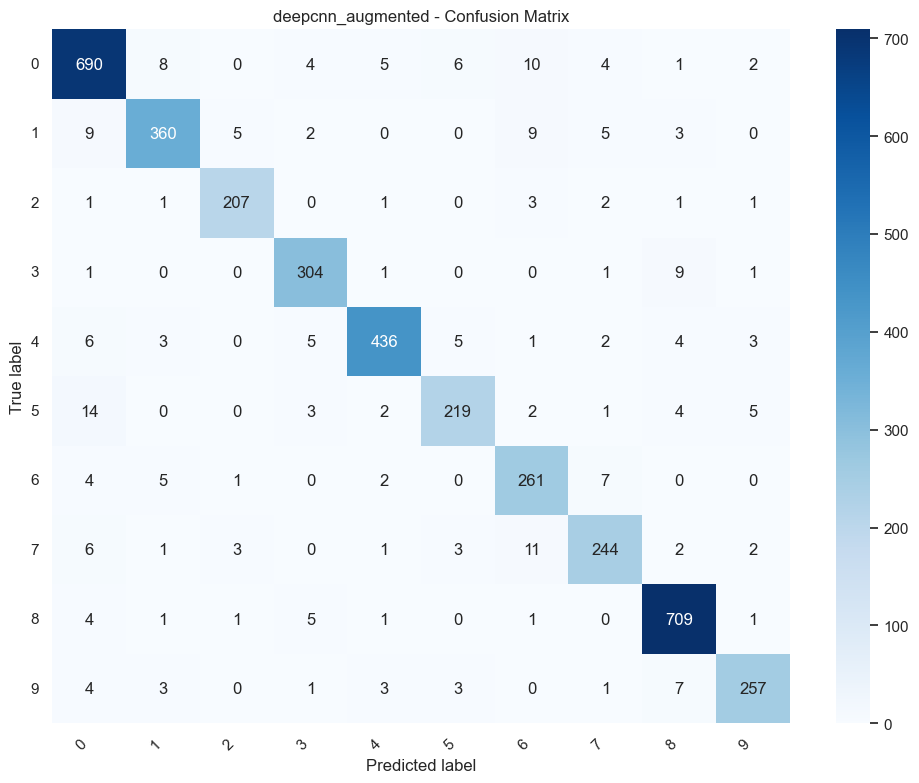

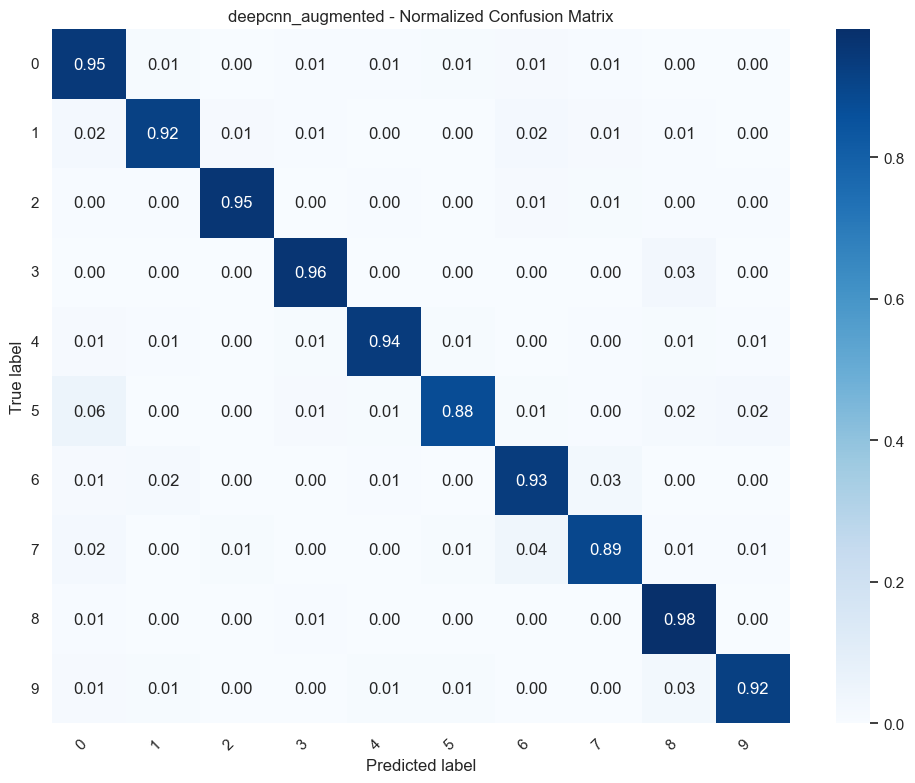


Per-class accuracy:


,class_id,class_name_en,correct,total,accuracy
0,0,dog,690,730,94.52%
1,1,horse,360,393,91.60%
2,2,elephant,207,217,95.39%
3,3,butterfly,304,317,95.90%
4,4,chicken,436,465,93.76%
5,5,cat,219,250,87.60%
6,6,cow,261,280,93.21%
7,7,sheep,244,273,89.38%
8,8,spider,709,723,98.06%
9,9,squirrel,257,279,92.11%



Classification report:


,precision,recall,f1-score,support
dog,0.933694,0.945205,0.939415,730.000000
horse,0.942408,0.916031,0.929032,393.000000
elephant,0.953917,0.953917,0.953917,217.000000
butterfly,0.938272,0.958991,0.948518,317.000000
chicken,0.964602,0.937634,0.950927,465.000000
cat,0.927966,0.876000,0.901235,250.000000
cow,0.875839,0.932143,0.903114,280.000000
sheep,0.913858,0.893773,0.903704,273.000000
spider,0.958108,0.980636,0.969241,723.000000
squirrel,0.944853,0.921147,0.932849,279.000000


Checkpoint: deepcnn_augmented_local_best.pt
Run name: deepcnn_augmented_local
Model: deep_cnn
Accuracy: 0.5640
Precision macro: 0.5604
Recall macro: 0.5074
F1 macro: 0.5157


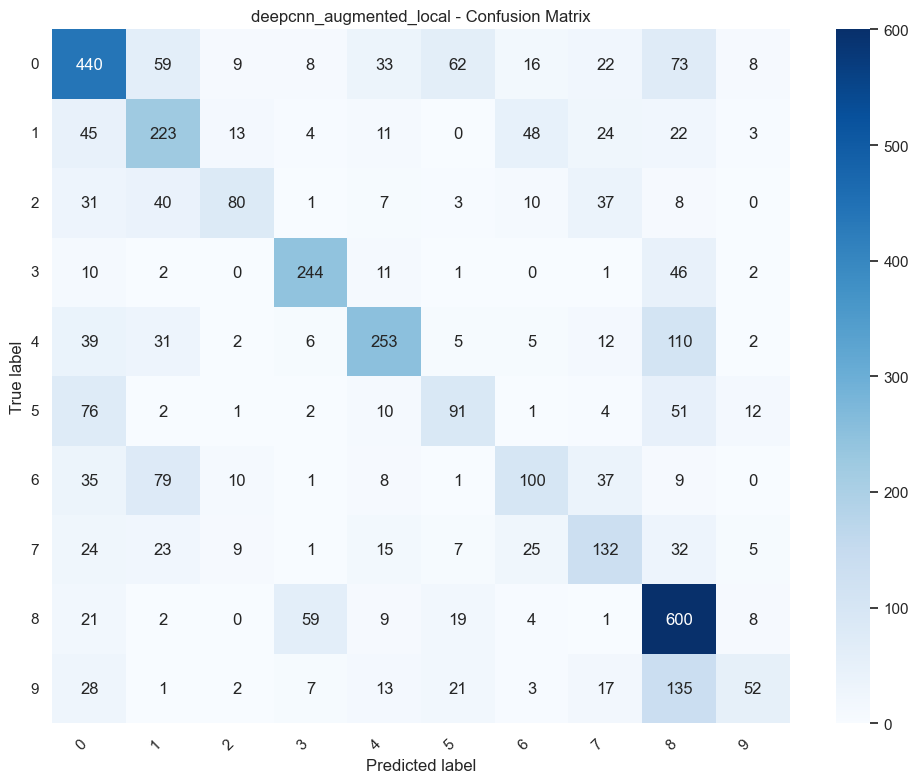

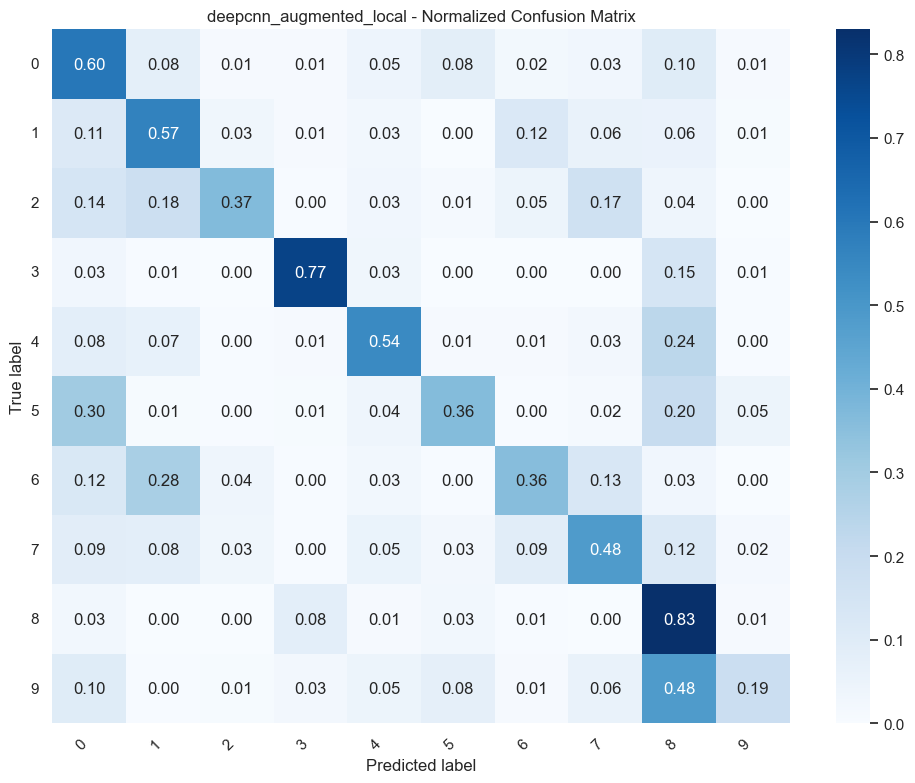


Per-class accuracy:


,class_id,class_name_en,correct,total,accuracy
0,0,dog,440,730,60.27%
1,1,horse,223,393,56.74%
2,2,elephant,80,217,36.87%
3,3,butterfly,244,317,76.97%
4,4,chicken,253,465,54.41%
5,5,cat,91,250,36.40%
6,6,cow,100,280,35.71%
7,7,sheep,132,273,48.35%
8,8,spider,600,723,82.99%
9,9,squirrel,52,279,18.64%



Classification report:


,precision,recall,f1-score,support
dog,0.587450,0.602740,0.594997,730.000000
horse,0.482684,0.567430,0.521637,393.000000
elephant,0.634921,0.368664,0.466472,217.000000
butterfly,0.732733,0.769716,0.750769,317.000000
chicken,0.683784,0.544086,0.605988,465.000000
cat,0.433333,0.364000,0.395652,250.000000
cow,0.471698,0.357143,0.406504,280.000000
sheep,0.459930,0.483516,0.471429,273.000000
spider,0.552486,0.829876,0.663350,723.000000
squirrel,0.565217,0.186380,0.280323,279.000000


Checkpoint: deepcnn_augmented_stronger_best.pt
Run name: deepcnn_augmented_stronger
Model: deep_cnn
Accuracy: 0.8859
Precision macro: 0.8820
Recall macro: 0.8768
F1 macro: 0.8789


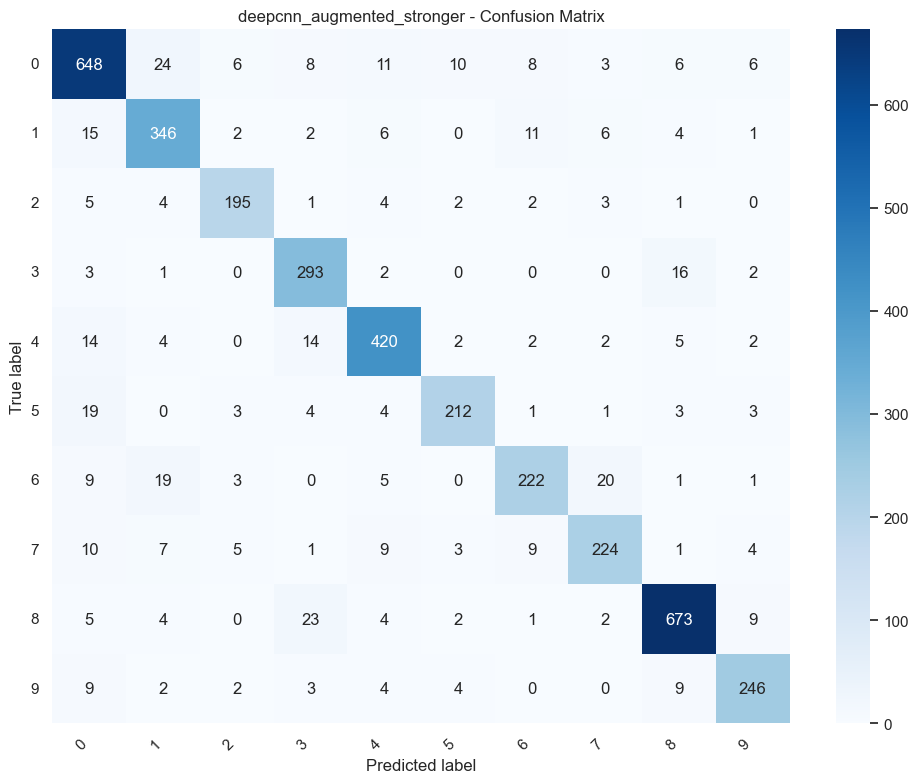

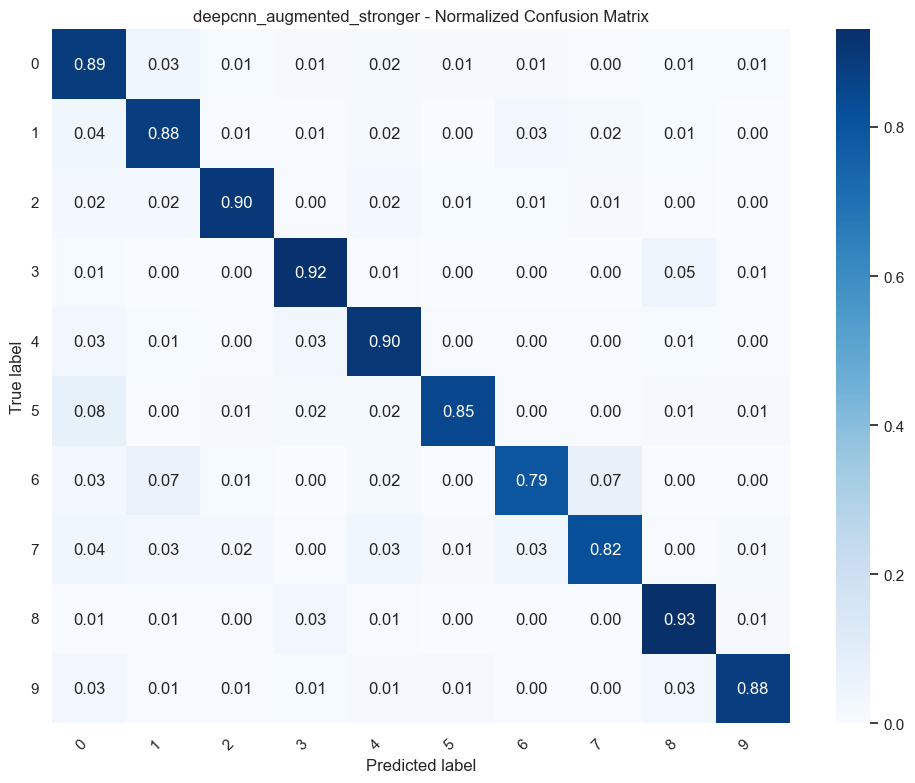


Per-class accuracy:


,class_id,class_name_en,correct,total,accuracy
0,0,dog,648,730,88.77%
1,1,horse,346,393,88.04%
2,2,elephant,195,217,89.86%
3,3,butterfly,293,317,92.43%
4,4,chicken,420,465,90.32%
5,5,cat,212,250,84.80%
6,6,cow,222,280,79.29%
7,7,sheep,224,273,82.05%
8,8,spider,673,723,93.08%
9,9,squirrel,246,279,88.17%



Classification report:


,precision,recall,f1-score,support
dog,0.879240,0.887671,0.883436,730.000000
horse,0.841849,0.880407,0.860697,393.000000
elephant,0.902778,0.898618,0.900693,217.000000
butterfly,0.839542,0.924290,0.879880,317.000000
chicken,0.895522,0.903226,0.899358,465.000000
cat,0.902128,0.848000,0.874227,250.000000
cow,0.867188,0.792857,0.828358,280.000000
sheep,0.858238,0.820513,0.838951,273.000000
spider,0.936022,0.930844,0.933426,723.000000
squirrel,0.897810,0.881720,0.889693,279.000000


Checkpoint: resnet18_finetune_best.pt
Run name: resnet18_finetune
Model: resnet18_transfer
Accuracy: 0.9730
Precision macro: 0.9716
Recall macro: 0.9701
F1 macro: 0.9707


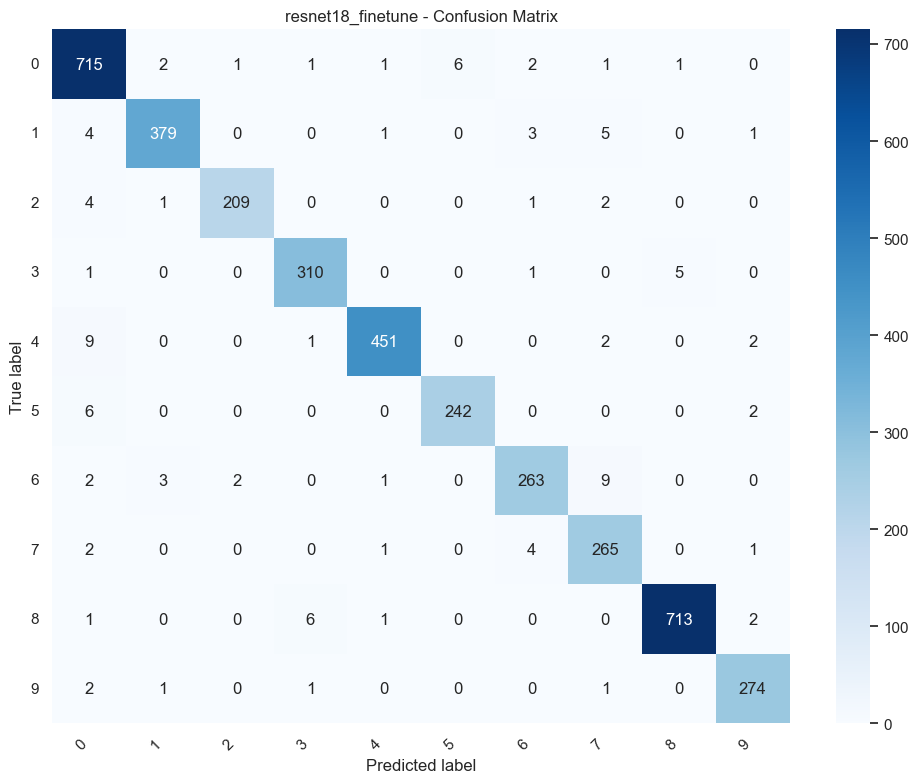

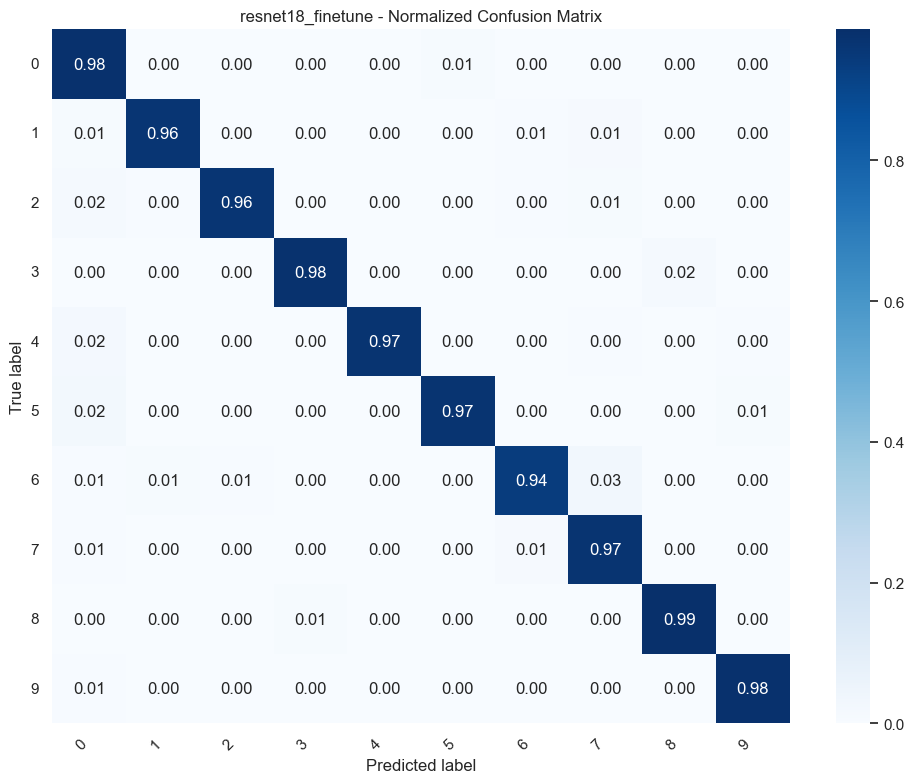


Per-class accuracy:


,class_id,class_name_en,correct,total,accuracy
0,0,dog,715,730,97.95%
1,1,horse,379,393,96.44%
2,2,elephant,209,217,96.31%
3,3,butterfly,310,317,97.79%
4,4,chicken,451,465,96.99%
5,5,cat,242,250,96.80%
6,6,cow,263,280,93.93%
7,7,sheep,265,273,97.07%
8,8,spider,713,723,98.62%
9,9,squirrel,274,279,98.21%



Classification report:


,precision,recall,f1-score,support
dog,0.958445,0.979452,0.968835,730.000000
horse,0.981865,0.964377,0.973042,393.000000
elephant,0.985849,0.963134,0.974359,217.000000
butterfly,0.971787,0.977918,0.974843,317.000000
chicken,0.989035,0.969892,0.979370,465.000000
cat,0.975806,0.968000,0.971888,250.000000
cow,0.959854,0.939286,0.949458,280.000000
sheep,0.929825,0.970696,0.949821,273.000000
spider,0.991655,0.986169,0.988904,723.000000
squirrel,0.971631,0.982079,0.976827,279.000000


Checkpoint: resnet18_frozen_head_best.pt
Run name: resnet18_frozen_head
Model: resnet18_transfer
Accuracy: 0.9649
Precision macro: 0.9612
Recall macro: 0.9591
F1 macro: 0.9599


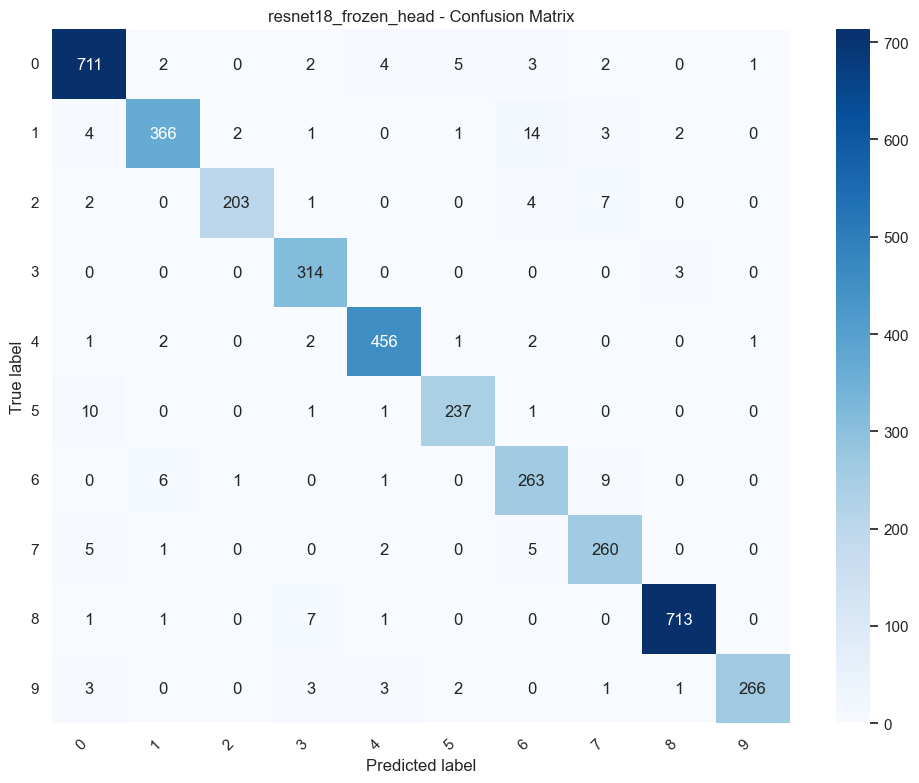

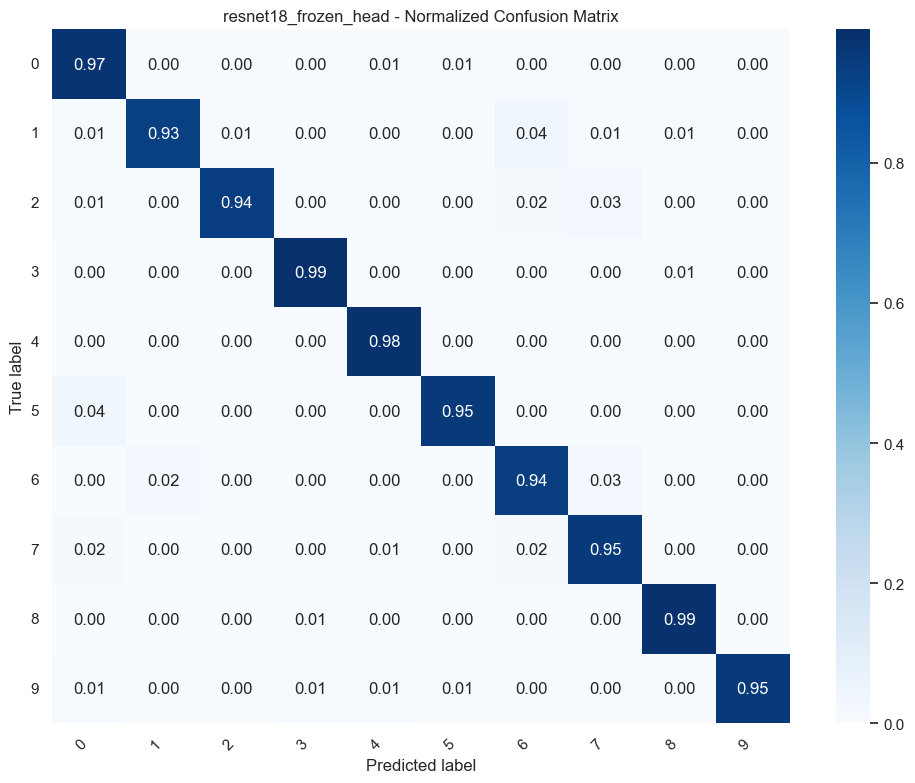


Per-class accuracy:


,class_id,class_name_en,correct,total,accuracy
0,0,dog,711,730,97.40%
1,1,horse,366,393,93.13%
2,2,elephant,203,217,93.55%
3,3,butterfly,314,317,99.05%
4,4,chicken,456,465,98.06%
5,5,cat,237,250,94.80%
6,6,cow,263,280,93.93%
7,7,sheep,260,273,95.24%
8,8,spider,713,723,98.62%
9,9,squirrel,266,279,95.34%



Classification report:


,precision,recall,f1-score,support
dog,0.964722,0.973973,0.969325,730.000000
horse,0.968254,0.931298,0.949416,393.000000
elephant,0.985437,0.935484,0.959811,217.000000
butterfly,0.948640,0.990536,0.969136,317.000000
chicken,0.974359,0.980645,0.977492,465.000000
cat,0.963415,0.948000,0.955645,250.000000
cow,0.900685,0.939286,0.919580,280.000000
sheep,0.921986,0.952381,0.936937,273.000000
spider,0.991655,0.986169,0.988904,723.000000
squirrel,0.992537,0.953405,0.972578,279.000000


Checkpoint: smallcnn_augmented_local_best.pt
Run name: smallcnn_augmented_local
Model: small_cnn
Accuracy: 0.6351
Precision macro: 0.6640
Recall macro: 0.5999
F1 macro: 0.5944


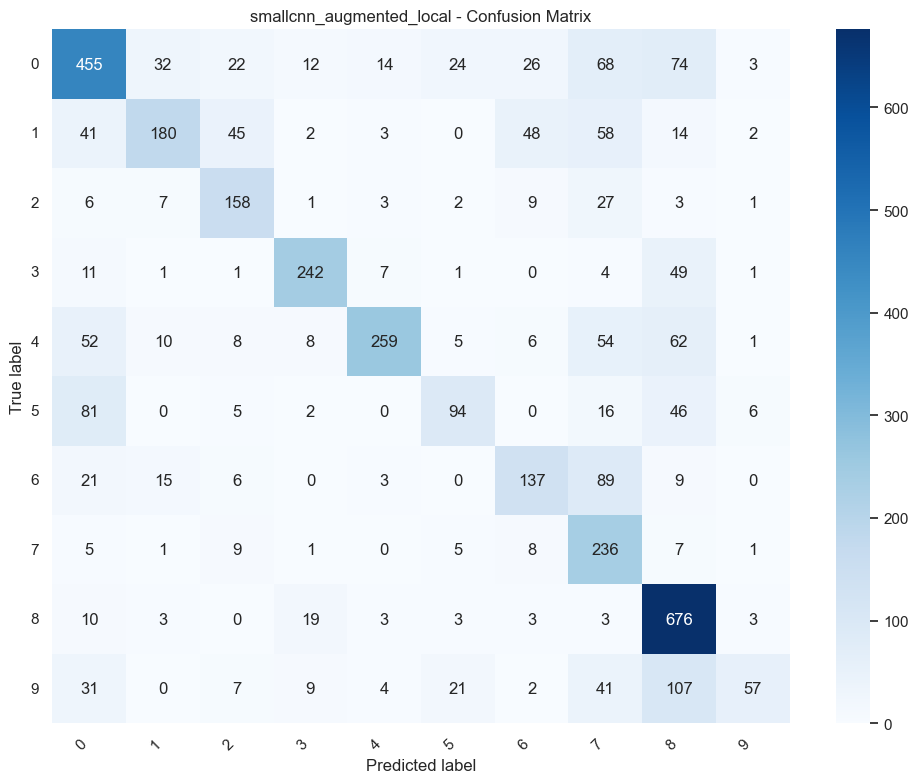

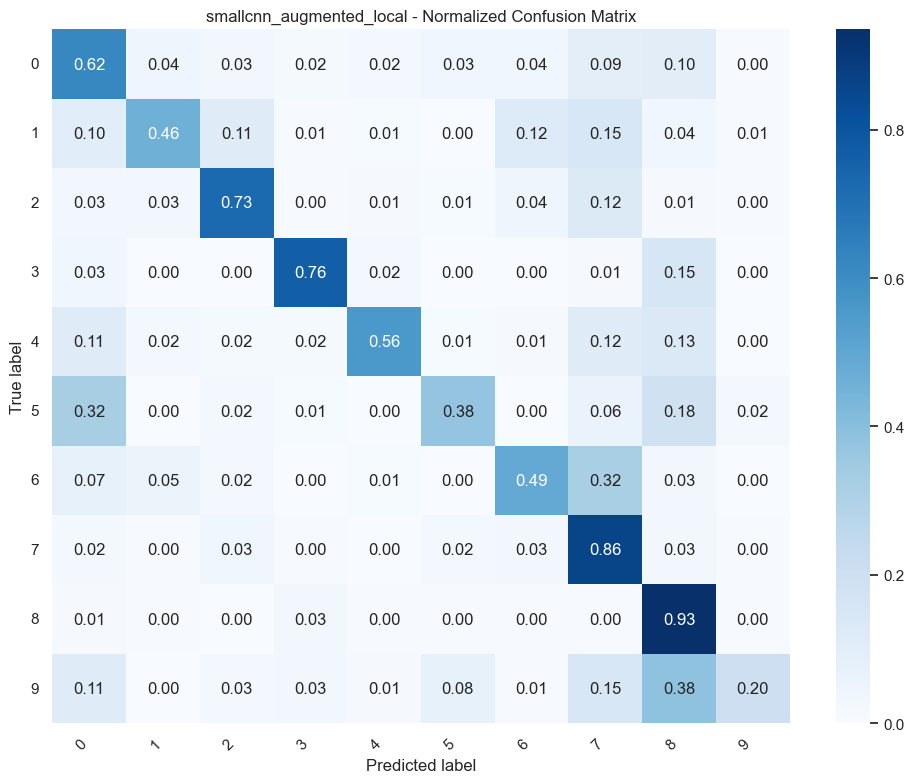


Per-class accuracy:


,class_id,class_name_en,correct,total,accuracy
0,0,dog,455,730,62.33%
1,1,horse,180,393,45.80%
2,2,elephant,158,217,72.81%
3,3,butterfly,242,317,76.34%
4,4,chicken,259,465,55.70%
5,5,cat,94,250,37.60%
6,6,cow,137,280,48.93%
7,7,sheep,236,273,86.45%
8,8,spider,676,723,93.50%
9,9,squirrel,57,279,20.43%



Classification report:


,precision,recall,f1-score,support
dog,0.638149,0.623288,0.630631,730.00000
horse,0.722892,0.458015,0.560748,393.00000
elephant,0.605364,0.728111,0.661088,217.00000
butterfly,0.817568,0.763407,0.789560,317.00000
chicken,0.875000,0.556989,0.680683,465.00000
cat,0.606452,0.376000,0.464198,250.00000
cow,0.573222,0.489286,0.527938,280.00000
sheep,0.395973,0.864469,0.543153,273.00000
spider,0.645654,0.934993,0.763842,723.00000
squirrel,0.760000,0.204301,0.322034,279.00000


Checkpoint: smallcnn_augmented_longer_best.pt
Run name: smallcnn_augmented_longer
Model: small_cnn
Accuracy: 0.8640
Precision macro: 0.8634
Recall macro: 0.8486
F1 macro: 0.8552


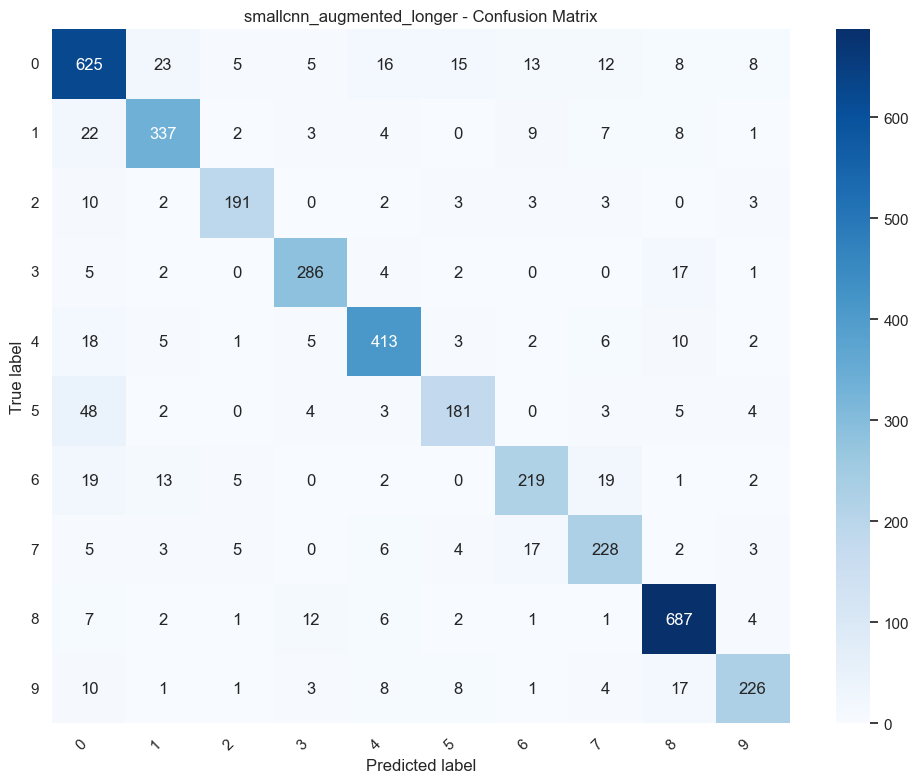

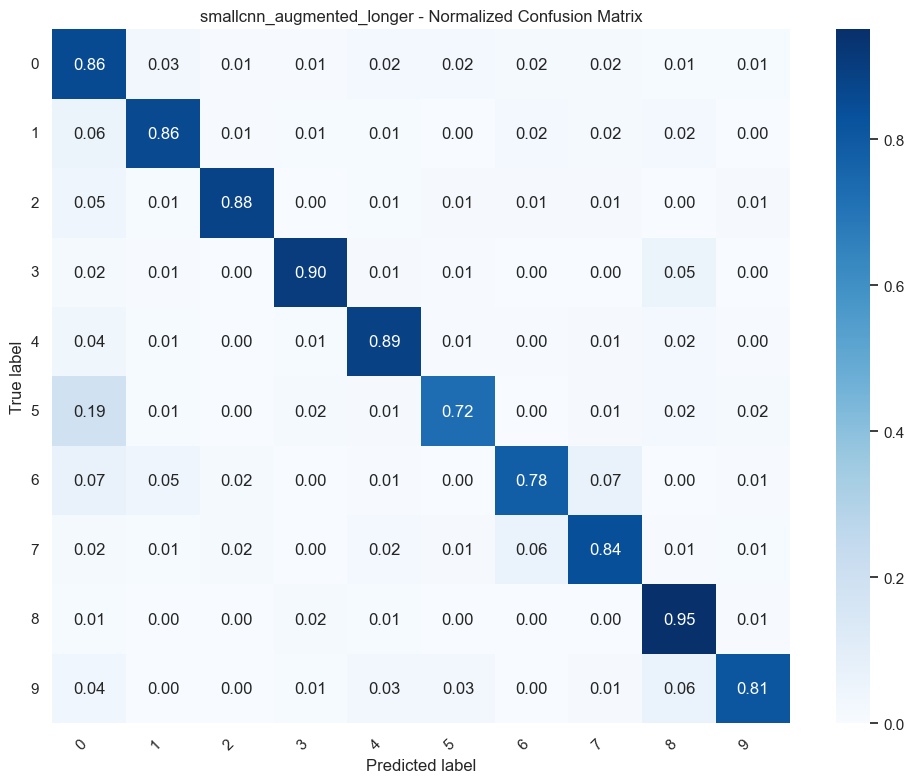


Per-class accuracy:


,class_id,class_name_en,correct,total,accuracy
0,0,dog,625,730,85.62%
1,1,horse,337,393,85.75%
2,2,elephant,191,217,88.02%
3,3,butterfly,286,317,90.22%
4,4,chicken,413,465,88.82%
5,5,cat,181,250,72.40%
6,6,cow,219,280,78.21%
7,7,sheep,228,273,83.52%
8,8,spider,687,723,95.02%
9,9,squirrel,226,279,81.00%



Classification report:


,precision,recall,f1-score,support
dog,0.812744,0.856164,0.833889,730.000000
horse,0.864103,0.857506,0.860792,393.000000
elephant,0.905213,0.880184,0.892523,217.000000
butterfly,0.899371,0.902208,0.900787,317.000000
chicken,0.890086,0.888172,0.889128,465.000000
cat,0.830275,0.724000,0.773504,250.000000
cow,0.826415,0.782143,0.803670,280.000000
sheep,0.805654,0.835165,0.820144,273.000000
spider,0.909934,0.950207,0.929635,723.000000
squirrel,0.889764,0.810036,0.848030,279.000000


Checkpoint: smallcnn_baseline_local_best.pt
Run name: smallcnn_baseline_local
Model: small_cnn
Accuracy: 0.6560
Precision macro: 0.6692
Recall macro: 0.6360
F1 macro: 0.6352


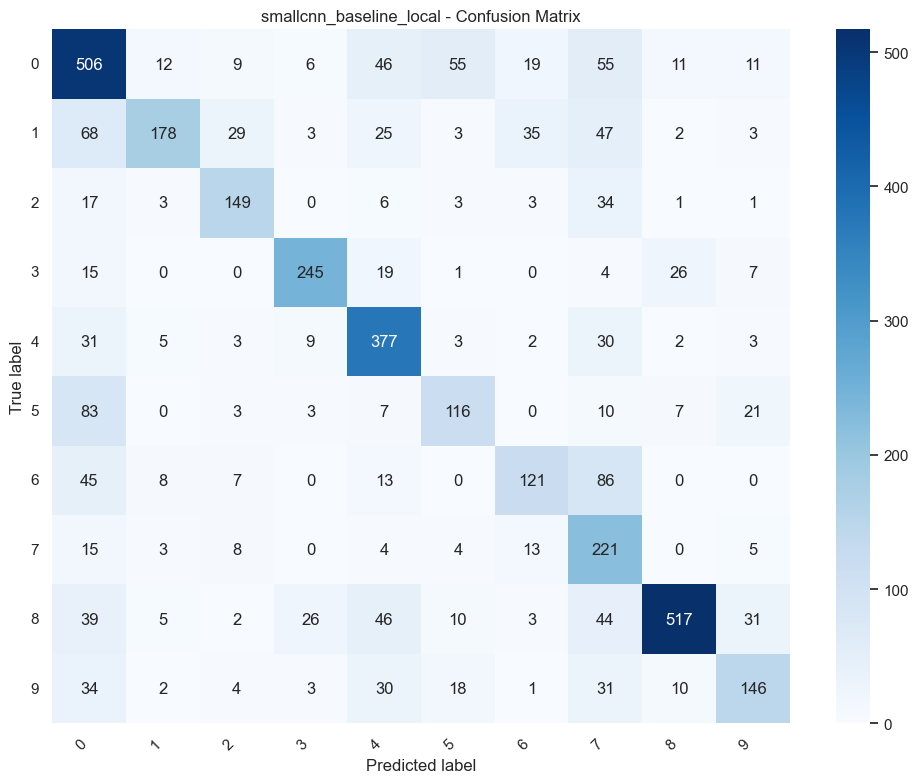

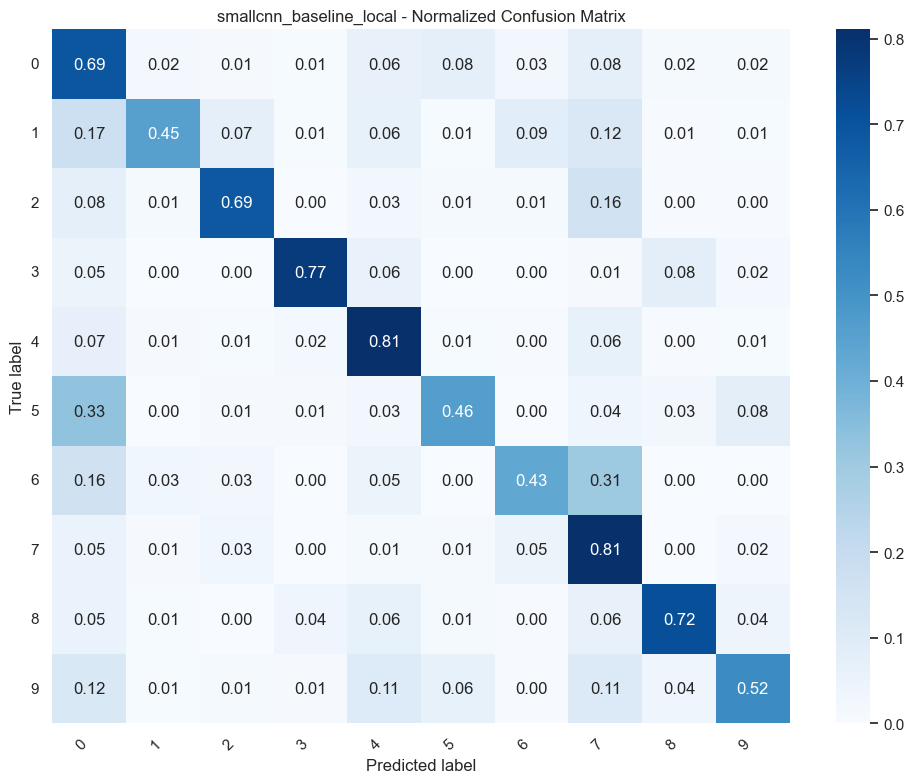


Per-class accuracy:


,class_id,class_name_en,correct,total,accuracy
0,0,dog,506,730,69.32%
1,1,horse,178,393,45.29%
2,2,elephant,149,217,68.66%
3,3,butterfly,245,317,77.29%
4,4,chicken,377,465,81.08%
5,5,cat,116,250,46.40%
6,6,cow,121,280,43.21%
7,7,sheep,221,273,80.95%
8,8,spider,517,723,71.51%
9,9,squirrel,146,279,52.33%



Classification report:


,precision,recall,f1-score,support
dog,0.593200,0.693151,0.639292,730.000000
horse,0.824074,0.452926,0.584565,393.000000
elephant,0.696262,0.686636,0.691415,217.000000
butterfly,0.830508,0.772871,0.800654,317.000000
chicken,0.657941,0.810753,0.726397,465.000000
cat,0.544601,0.464000,0.501080,250.000000
cow,0.614213,0.432143,0.507338,280.000000
sheep,0.393238,0.809524,0.529341,273.000000
spider,0.897569,0.715076,0.795997,723.000000
squirrel,0.640351,0.523297,0.575937,279.000000


Checkpoint: smallcnn_baseline_longer_best.pt
Run name: smallcnn_baseline_longer
Model: small_cnn
Accuracy: 0.7970
Precision macro: 0.7965
Recall macro: 0.7786
F1 macro: 0.7839


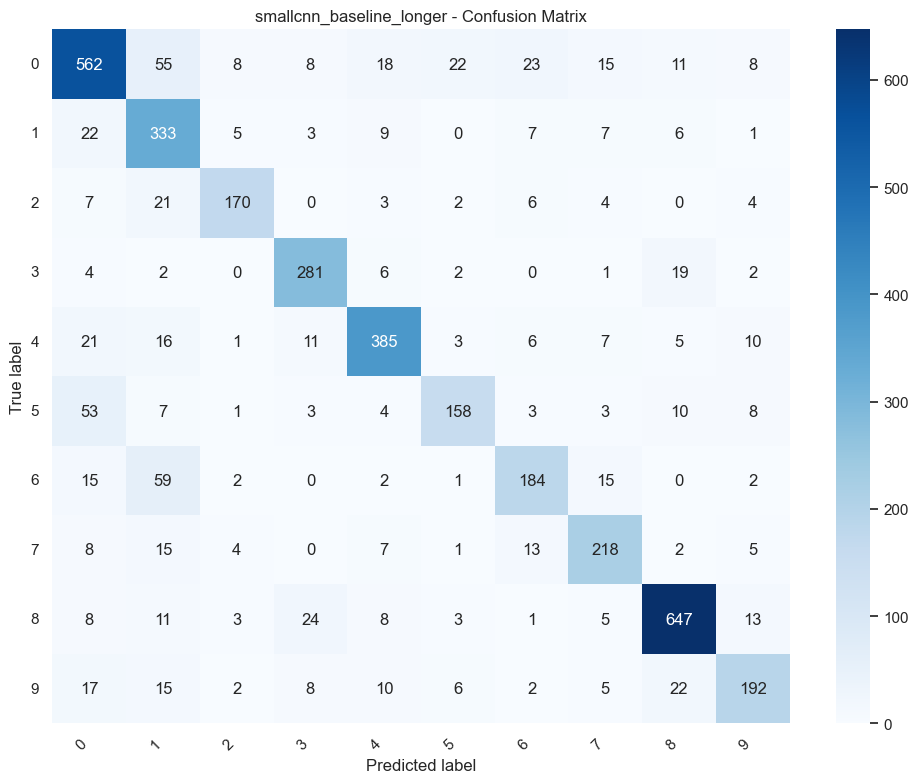

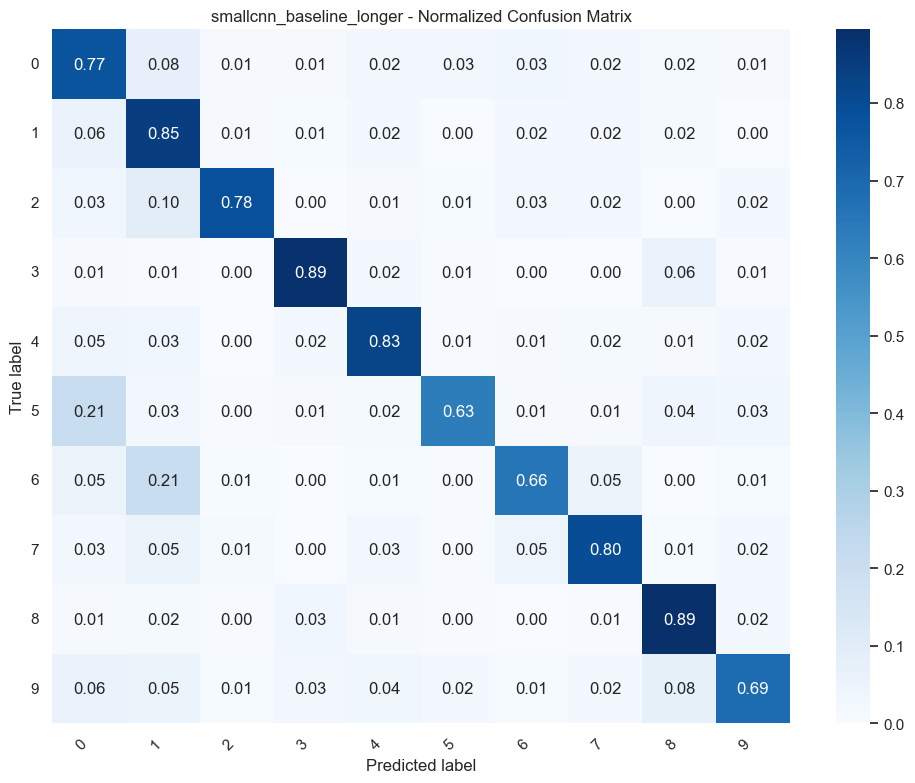


Per-class accuracy:


,class_id,class_name_en,correct,total,accuracy
0,0,dog,562,730,76.99%
1,1,horse,333,393,84.73%
2,2,elephant,170,217,78.34%
3,3,butterfly,281,317,88.64%
4,4,chicken,385,465,82.80%
5,5,cat,158,250,63.20%
6,6,cow,184,280,65.71%
7,7,sheep,218,273,79.85%
8,8,spider,647,723,89.49%
9,9,squirrel,192,279,68.82%



Classification report:


,precision,recall,f1-score,support
dog,0.783821,0.769863,0.776780,730.000000
horse,0.623596,0.847328,0.718447,393.000000
elephant,0.867347,0.783410,0.823245,217.000000
butterfly,0.831361,0.886435,0.858015,317.000000
chicken,0.851770,0.827957,0.839695,465.000000
cat,0.797980,0.632000,0.705357,250.000000
cow,0.751020,0.657143,0.700952,280.000000
sheep,0.778571,0.798535,0.788427,273.000000
spider,0.896122,0.894882,0.895502,723.000000
squirrel,0.783673,0.688172,0.732824,279.000000


In [32]:
for ckpt_name, obj in all_eval_objects.items():
    config = obj["config"]
    metrics = obj["metrics"]

    print("=" * 90)
    print("Checkpoint:", ckpt_name)
    print("Run name:", config.get("run_name"))
    print("Model:", config["model_name"])
    print(f"Accuracy: {metrics['accuracy']:.4f}")
    print(f"Precision macro: {metrics['precision_macro']:.4f}")
    print(f"Recall macro: {metrics['recall_macro']:.4f}")
    print(f"F1 macro: {metrics['f1_macro']:.4f}")

    plot_confusion_matrix(
        metrics["confusion_matrix"],
        id_to_label,
        title=f"{config.get('run_name', ckpt_name)} - Confusion Matrix",
        normalize=False,
        figsize=(10, 8),
    )

    plot_confusion_matrix(
        metrics["confusion_matrix"],
        id_to_label,
        title=f"{config.get('run_name', ckpt_name)} - Normalized Confusion Matrix",
        normalize=True,
        figsize=(10, 8),
    )

    print("\nPer-class accuracy:")
    display(
        metrics["per_class_accuracy_df"].style.format({"accuracy": "{:.2%}"})
    )

    print("\nClassification report:")
    display(metrics["classification_report_df"])

### Ako čítať confusion matrix a klasifikačné reporty

Pri každom checkpointe sa zobrazujú dve confusion matrixy. Nenormalizovaná verzia ukazuje absolútne počty chýb, teda koľko vzoriek konkrétnej triedy model zaradil inde. Normalizovaná verzia je vhodnejšia na porovnanie medzi triedami, pretože prevádza riadky na podiely a odstráni vplyv rôzneho počtu obrázkov v triedach.

Per-class accuracy tabuľka je najpriamejší pohľad na to, na ktorých triedach sa modelu darí. Klasifikačný report to rozširuje o `precision`, `recall` a `f1-score`.

Pri interpretácii je dobré sledovať najmä tieto vzory:
- Ak má trieda vysoký `precision`, ale nižší `recall`, model ju predikuje opatrne a často ju prehliada.
- Ak má trieda vysoký `recall`, ale slabší `precision`, model ju síce často trafí, ale zároveň do nej hádže aj cudzie vzorky.
- Off-diagonal polia v confusion matrix ukazujú konkrétne dvojice tried, ktoré sa modelu pletú. To je často hodnotnejšie než samotná jedna agregovaná accuracy.


## 13. Interpretácia pomocou Grad-CAM

Po výbere najlepšieho modelu sa pozrieme ešte na to, kam sa model pri rozhodovaní pozerá. Grad-CAM nám umožní zvýrazniť oblasti obrázka, ktoré najviac prispeli k predikcii.

Zameriame sa na chybne klasifikované príklady, pretože práve tam je interpretácia najzaujímavejšia: vieme zistiť, či sa model sústreďuje na relevantnú časť zvieraťa, alebo či sa nechal pomýliť pozadím, textúrou či iným objektom v scéne.


In [33]:
class GradCAM:
    def __init__(self, model, target_layer):
        self.model = model
        self.target_layer = target_layer
        self.activations = None
        self.gradients = None

        self.forward_hook = target_layer.register_forward_hook(self._forward_hook)

    def _forward_hook(self, module, inputs, output):
        self.activations = output
        self.gradients = None

        def save_gradients(grad):
            self.gradients = grad

        output.register_hook(save_gradients)

    def remove_hooks(self):
        self.forward_hook.remove()

    def __call__(self, input_tensor, target_class=None):
        self.model.zero_grad()

        output = self.model(input_tensor)

        if target_class is None:
            target_class = output.argmax(dim=1).item()

        score = output[:, target_class]
        score.backward()

        if self.gradients is None:
            raise RuntimeError(
                "Grad-CAM gradients were not captured. "
                "Check the target layer and make sure the model/layer is not fully frozen."
            )

        grads = self.gradients[0]      # [C, H, W]
        acts = self.activations[0]     # [C, H, W]

        weights = grads.mean(dim=(1, 2))
        cam = torch.zeros(acts.shape[1:], device=acts.device)

        for i, w in enumerate(weights):
            cam += w * acts[i]

        cam = F.relu(cam)
        cam -= cam.min()
        cam /= (cam.max() + 1e-8)

        return cam.detach().cpu().numpy(), target_class

In [34]:
def get_target_layer(model, model_name):
    if model_name == "resnet18_transfer":
        return model.layer4[-1].conv2

    elif model_name in ["small_cnn", "deep_cnn"]:
        conv_layers = [m for m in model.features.modules() if isinstance(m, nn.Conv2d)]
        if not conv_layers:
            raise ValueError(f"No Conv2d layer found for {model_name}")
        return conv_layers[-1]

    else:
        raise ValueError(f"No target layer rule for model_name={model_name}")

In [35]:
def denormalize_image(tensor, mean=IMAGENET_MEAN, std=IMAGENET_STD):
    img = tensor.detach().cpu().numpy().transpose(1, 2, 0)
    mean = np.array(mean)
    std = np.array(std)
    img = img * std + mean
    img = np.clip(img, 0, 1)
    return img

def overlay_cam_on_image(img_rgb, cam, alpha=0.4):
    cam_resized = cv2.resize(cam, (img_rgb.shape[1], img_rgb.shape[0]))
    heatmap = np.uint8(255 * cam_resized)
    heatmap = cv2.applyColorMap(heatmap, cv2.COLORMAP_JET)
    heatmap = cv2.cvtColor(heatmap, cv2.COLOR_BGR2RGB) / 255.0

    overlay = (1 - alpha) * img_rgb + alpha * heatmap
    overlay = np.clip(overlay, 0, 1)
    return cam_resized, overlay

def show_gradcam_examples(model, model_name, dataset, id_to_label_en, num_examples=6, only_misclassified=False):
    model.eval()

    target_layer = get_target_layer(model, model_name)
    gradcam = GradCAM(model, target_layer)

    shown = 0
    idx = 0

    plt.figure(figsize=(14, 4 * num_examples))

    while idx < len(dataset) and shown < num_examples:
        image_tensor, true_label = dataset[idx]
        input_tensor = image_tensor.unsqueeze(0).to(DEVICE)

        logits = model(input_tensor)
        pred_label = logits.argmax(dim=1).item()
        prob = F.softmax(logits, dim=1)[0, pred_label].item()

        if only_misclassified and pred_label == true_label:
            idx += 1
            continue

        cam, target_class = gradcam(input_tensor, target_class=pred_label)

        img_rgb = denormalize_image(image_tensor)
        cam_resized, overlay = overlay_cam_on_image(img_rgb, cam, alpha=0.4)

        row = shown * 3

        plt.subplot(num_examples, 3, row + 1)
        plt.imshow(img_rgb)
        plt.title(f"Original\nTrue: {id_to_label_en[true_label]}")
        plt.axis("off")

        plt.subplot(num_examples, 3, row + 2)
        plt.imshow(cam_resized, cmap="jet")
        plt.title("Grad-CAM heatmap")
        plt.axis("off")

        plt.subplot(num_examples, 3, row + 3)
        plt.imshow(overlay)
        plt.title(f"Pred: {id_to_label_en[pred_label]} ({prob:.2%})")
        plt.axis("off")

        shown += 1
        idx += 1

    gradcam.remove_hooks()
    plt.tight_layout()
    plt.show()

Best model: resnet18_finetune - resnet18_transfer


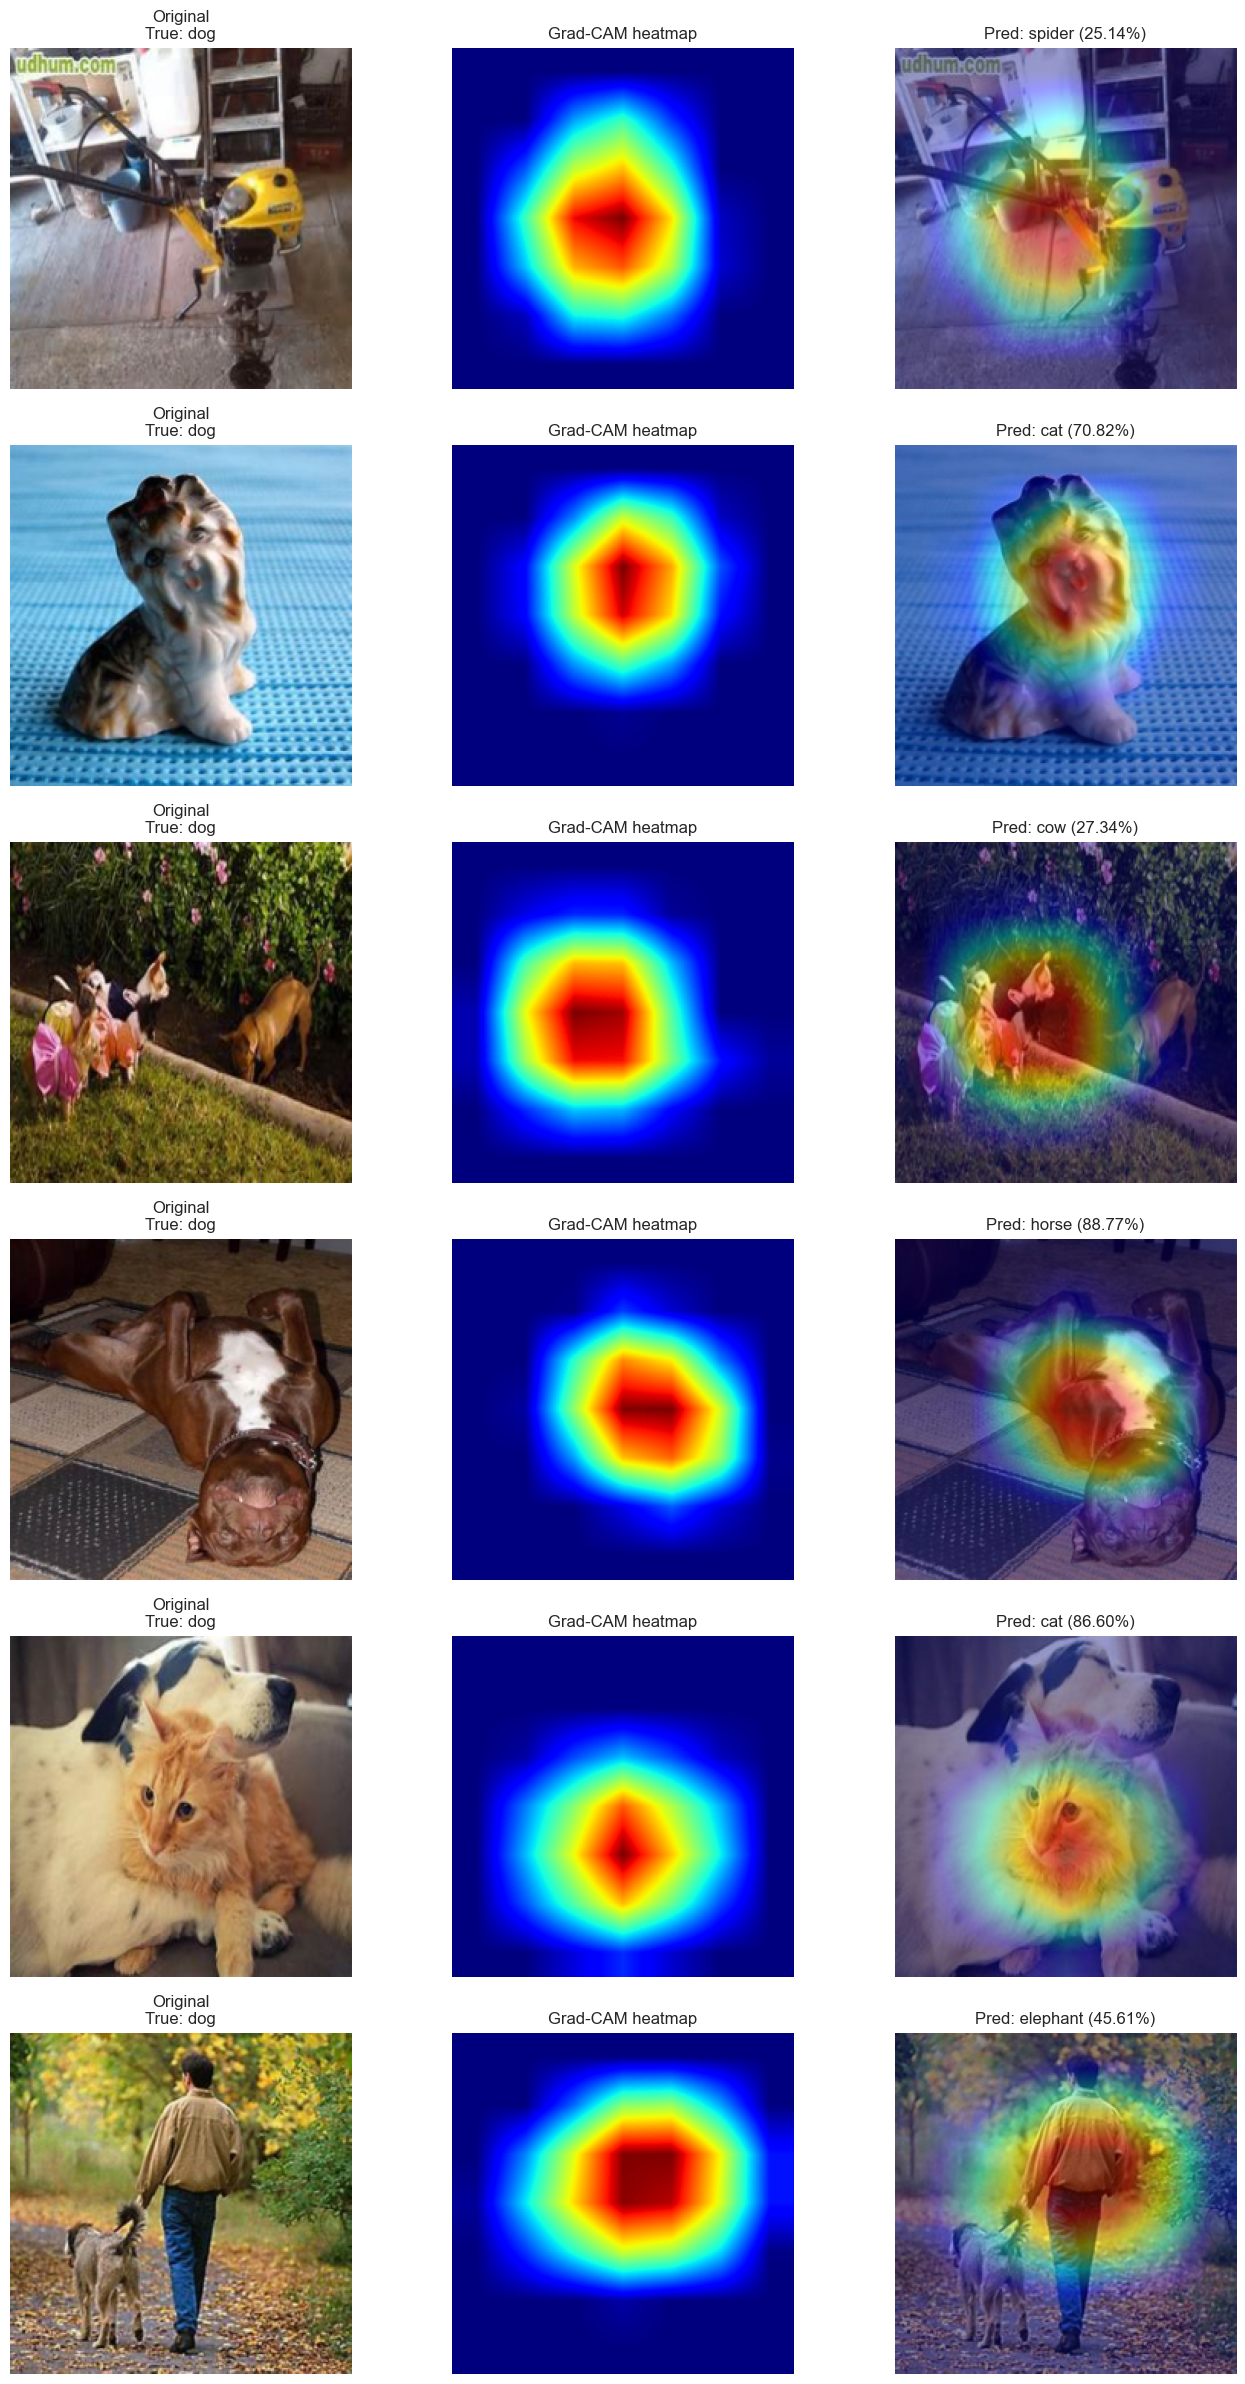

In [36]:
best_ckpt_name = eval_df.iloc[0]["checkpoint"]
best_obj = all_eval_objects[best_ckpt_name]

best_model = best_obj["model"]
best_config = best_obj["config"]

print("Best model:", best_config.get("run_name"), "-", best_config["model_name"])

show_gradcam_examples(
    model=best_model,
    model_name=best_config["model_name"],
    dataset=test_eval_ds,
    id_to_label_en=id_to_label_en,
    num_examples=6,
    only_misclassified=True,
)

### Čo sme videli na Grad-CAM vizualizáciách

Ako najlepší model bol vybraný `resnet18_finetune - resnet18_transfer`, čo je v súlade s tabuľkou metrík vyššie.

Vizualizácie nad chybne klasifikovanými vzorkami slúžia na kvalitatívnu kontrolu. Ak heatmapa dopadá na telo, hlavu alebo výrazné časti zvieraťa, model sa pravdepodobne rozhoduje na základe zmysluplných znakov. Ak sa sústredí skôr na pozadie, trávu, konáre alebo iné objekty mimo zvieraťa, ide o signál, že časť chýb môže byť spôsobená kontextom scény a nie samotnou triedou.
